In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [2]:
import numpy as np
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import scanorama
import ot

In [3]:
filePath='/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity'

In [4]:
fileName='data_design_05_24_2024.xlsx'
fileName = os.path.join(filePath, fileName)
exp_design_df = pd.read_excel(fileName)

In [5]:
exp_design_df

,groupName,dayName,tissueName,fileName
0,E0,7,1,E0_day_7_tissue_1_merged_df_05_18_2024.csv
1,E0,7,2,E0_day_7_tissue_2_merged_df_05_18_2024.csv
2,E0,7,4,E0_day_7_tissue_4_merged_df_05_18_2024.csv
3,E0,14,2,E0_day_14_tissue_2_merged_df_05_18_2024.csv
4,E0,14,3,E0_day_14_tissue_3_merged_df_05_18_2024.csv
5,E0,14,4,E0_day_14_tissue_4_merged_df_cleaned_05_18_202...
6,E0,21,1,E0_day_21_tissue_1_merged_df_cleaned_05_18_202...
7,E0,21,3,E0_day_21_tissue_3_merged_df_05_18_2024.csv
8,4T1,7,1,4T1_day_7_tissue_1_merged_df_05_18_2024.csv
9,4T1,7,4,4T1_day_7_tissue_4_merged_df_05_18_2024.csv


In [6]:
print(exp_design_df.dtypes)

groupName     object
dayName        int64
tissueName     int64
fileName      object
dtype: object


In [7]:
#exp_design_df = exp_design_df[(exp_design_df['groupName'] == '4T1') & (exp_design_df['dayName'] == 7)]

In [8]:
#exp_design_df = exp_design_df[(exp_design_df['groupName'] == '4T1')]

In [9]:
exp_design_df = exp_design_df[(exp_design_df['dayName'] != 21)]

In [10]:
exp_design_df

,groupName,dayName,tissueName,fileName
0,E0,7,1,E0_day_7_tissue_1_merged_df_05_18_2024.csv
1,E0,7,2,E0_day_7_tissue_2_merged_df_05_18_2024.csv
2,E0,7,4,E0_day_7_tissue_4_merged_df_05_18_2024.csv
3,E0,14,2,E0_day_14_tissue_2_merged_df_05_18_2024.csv
4,E0,14,3,E0_day_14_tissue_3_merged_df_05_18_2024.csv
5,E0,14,4,E0_day_14_tissue_4_merged_df_cleaned_05_18_202...
8,4T1,7,1,4T1_day_7_tissue_1_merged_df_05_18_2024.csv
9,4T1,7,4,4T1_day_7_tissue_4_merged_df_05_18_2024.csv
10,4T1,7,5,4T1_day_7_tissue_5_merged_df_05_18_2024.csv
11,4T1,14,3,4T1_day_14_tissue_3_merged_df_05_18_2024.csv


In [11]:
def spin_custom_message_passing_for_two_modalities_v1(adata_mode_1,
                                                      adata_mode_2,
                                                      n_neighbors=4, 
                                                      subsample_percentage=0.75, 
                                                      coord_type="generic", 
                                                      mode: str = "l1_norm"):
    
    #from scipy.linalg import sqrtm
    import scipy.sparse as sp
    import squidpy as sq
    
    np.random.seed(0)
    
    adata_new_mode_1 = adata_mode_1.copy()
    adata_new_mode_2 = adata_mode_2.copy()
    
    sq.gr.spatial_neighbors(adata_new_mode_1, n_neighs=n_neighbors, coord_type=coord_type, set_diag=True)
    
    
    # use spin approach
    # https://www.biorxiv.org/content/10.1101/2023.06.30.547258v1
    def row_wise_random_subsample (a_csr_matrix, n_neighbors=8, subsample_percentage=0.3):
    
        n_subsamples = int(n_neighbors * subsample_percentage)

        print("n_neighbors: {}, n_subsamples: {}".format(n_neighbors, n_subsamples))
        
        tmp_row = a_csr_matrix[0,].toarray()
        ones_indices = np.where(tmp_row == 1)[1]
        n_nbr = len(ones_indices)
        
        print("n_nbr plus self: ", n_nbr)
        
        for idx in range(a_csr_matrix.shape[0]):
            tmp_row = a_csr_matrix[idx,].toarray()
            ones_indices = np.where(tmp_row == 1)[1]
            self_index = idx
            neighbor_indices = ones_indices[ ones_indices != self_index ]
            keep_neighbor_indices = np.random.choice(neighbor_indices, n_subsamples, replace=False)
            keep_indices = np.append(keep_neighbor_indices, self_index)

            for index in ones_indices:
                if index not in keep_indices:
                    a_csr_matrix[idx, index] = 0

        return a_csr_matrix       
    
    if mode == "l1_norm": # row-wise normalization in the network adjacency matrix
        
        A_csr_matrix = adata_new_mode_1.obsp["spatial_connectivities"].tocsr()
        
        A_csr_matrix_revised = row_wise_random_subsample(A_csr_matrix, n_neighbors, subsample_percentage)
        
        A_csc_matrix = A_csr_matrix_revised.tocsc()
        
        # Define the dimensions of the matrix
        n_dim = A_csc_matrix.shape[0]

        # Create a list to store the diagonal elements
        diag_elements = [1] * n_dim
        offsets = [0]  # Diagonal offset (0 for main diagonal)
        diag_csc_matrix = sp.spdiags(diag_elements, offsets, n_dim, n_dim).tocsc()
        #A_mod = np.asarray(A + np.eye(A.shape[0]))

        A_mod = A_csc_matrix + diag_csc_matrix
        
        row_sums = A_mod.sum(axis =1)
        affinity = A_mod/row_sums
        
        affinity.tocsr()
        
    else:
        # Plain A_mod multiplication
        A_csr_matrix = adata_new_mode_1.obsp["spatial_connectivities"].tocsr()
        
        A_csr_matrix_revised = row_wise_random_subsample(A_csr_matrix, n_neighbors, subsample_percentage)
        
        A_csr_matrix = A_csr_matrix_revised
        
        affinity = A_csr_matrix

    # inner product (message passing)    
    #adata_new = adata.copy()
    
    adata_new_mode_1.X = affinity @ adata_new_mode_1.X
    adata_new_mode_2.X = affinity @ adata_new_mode_2.X
    
    return adata_new_mode_1, adata_new_mode_2

In [12]:
def load_modality_intensity(fileName, groupName, dayName, tissueName):
    
    #fileName='E0_day_14_tissue_4_merged_df_05_18_2024.csv'
    #fileName = os.path.join(filePath, fileName)
    merged_df = pd.read_csv(fileName)
    
    merged_metadata_df = merged_df.iloc[:,0:9]
    
    spot_id_name = 'group_' + groupName + '_day_' + dayName + '_tissue_' + tissueName + '_posX_' + merged_metadata_df['transformed_pos_x'].astype(str) + '_posY_' + merged_metadata_df['transformed_pos_y'].astype(str)
    
    merged_MALDI_data_df = merged_df.iloc[:,15:233]
    
    merged_mIF_data_df = merged_df.iloc[:,10:15]
    
    # Function to multiply each value by 10^15
    #scale_factor = 10**15
    #scale_function = lambda x: np.log10(x * scale_factor + 1)
    
    #merged_MALDI_data_df = merged_MALDI_data_df.apply(scale_function, axis=0)
    
    adata_MALDI = sc.AnnData(merged_MALDI_data_df)
    
    group_id = 'group_' + groupName
    day_id = 'day_' + dayName
    tissue_id = 'tissue_' + tissueName

    adata_MALDI.obs['pos_y'] = merged_metadata_df['transformed_pos_y'].values
    adata_MALDI.obs['pos_x'] = merged_metadata_df['transformed_pos_x'].values
    adata_MALDI.obs['pixel_id'] = np.array(spot_id_name)
    adata_MALDI.obs['group_id'] = group_id
    adata_MALDI.obs['day_id'] = day_id
    adata_MALDI.obs['tissue_id'] = tissue_id
    adata_MALDI.obs['sample_id'] = 'group_' + groupName + '_day_' + dayName + '_tissue_' + tissueName
    
    sc.pp.filter_cells(adata_MALDI, min_genes=0)
    sc.pp.filter_genes(adata_MALDI, min_cells=0)
    adata_MALDI.obsm['spatial'] = np.array(adata_MALDI.obs[['pos_y', 'pos_x']])
    
    #####
    
    adata_mIF = sc.AnnData(merged_mIF_data_df)

    adata_mIF.obs['pos_y'] = merged_metadata_df['transformed_pos_y'].values
    adata_mIF.obs['pos_x'] = merged_metadata_df['transformed_pos_x'].values
    adata_mIF.obs['pixel_id'] = np.array(spot_id_name)
    adata_mIF.obs['group_id'] = group_id
    adata_mIF.obs['day_id'] = day_id
    adata_mIF.obs['tissue_id'] = tissue_id
    adata_mIF.obs['sample_id'] = 'group_' + groupName + '_day_' + dayName + '_tissue_' + tissueName

    sc.pp.filter_cells(adata_mIF, min_genes=0)
    sc.pp.filter_genes(adata_mIF, min_cells=0)
    adata_mIF.obsm['spatial'] = np.array(adata_mIF.obs[['pos_y', 'pos_x']])
    
    #####
    if False:
        # spatial smoothing section
        ot.tic()
        normalization_mode='l1_norm'
        ad_MALDI_revised_result, ad_mIF_revised_result = spin_custom_message_passing_for_two_modalities_v1(adata_MALDI, 
                                                                                    adata_mIF,
                                                                                    n_neighbors=4, 
                                                                                    subsample_percentage=0.75, 
                                                                                    coord_type="generic", 
                                                                                    mode=normalization_mode)
        ot.toc()

        print("Finish spatial smoothing")

        adata_MALDI = ad_MALDI_revised_result.copy()
        adata_mIF = ad_mIF_revised_result.copy()
    
    return adata_MALDI, adata_mIF
    
    

In [13]:
# Apply the function to each row in the filtered DataFrame
adatas_MALDI = []
adatas_mIF = []

for index, row in exp_design_df.iterrows():
    
    file_name = row['fileName']
    group_name = row['groupName']
    day_name = str(row['dayName'])
    tissue_name = str(row['tissueName'])
    
    batch = group_name + day_name + tissue_name
    
    print("loading group_" + group_name + "  day_"+ day_name + " tissue_" + tissue_name)
    
    filePath='/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/finished'
    file_name = os.path.join(filePath, file_name)
    
    adata_MALDI, adata_mIF = load_modality_intensity(file_name, group_name, day_name, tissue_name)
    
    #sc.pp.scale(adata_MALDI)
    #sc.pp.scale(adata_mIF)
    
    adatas_MALDI.append(adata_MALDI)
    adatas_mIF.append(adata_mIF)

loading group_E0  day_7 tissue_1


/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loading group_E0  day_7 tissue_2


/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loading group_E0  day_7 tissue_4


...

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loading group_4T1  day_14 tissue_4


/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loading group_4T1  day_14 tissue_5


/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
metabolite_names = adatas_MALDI[0].var.index.tolist()

In [121]:
adatas_MALDI_wo_scale = ad.concat(adatas_MALDI, join="inner")

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [123]:
adatas_MALDI_wo_scale.X

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.24044540e-12],
       [0.00000000e+00, 0.00000000e+00, 1.29073530e-12, ...,
        0.00000000e+00, 0.00000000e+00, 5.48536636e-12],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.83781356e-12, 1.39378647e-11],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 4.62496875e-12],
       [0.00000000e+00, 0.00000000e+00, 1.62851946e-12, ...,
        0.00000000e+00, 0.00000000e+00, 5.15423468e-12],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.01528707e-11]])

In [124]:
ad_MALDI_metadata_wo_scale_df = pd.DataFrame(adatas_MALDI_wo_scale.obs)

In [125]:
ad_MALDI_metadata_wo_scale_df

,pos_y,pos_x,pixel_id,group_id,day_id,tissue_id,sample_id,n_genes
0,66,127,group_E0_day_7_tissue_1_posX_127_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,10
1,66,126,group_E0_day_7_tissue_1_posX_126_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,34
2,66,130,group_E0_day_7_tissue_1_posX_130_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,64
3,66,129,group_E0_day_7_tissue_1_posX_129_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,93
4,66,128,group_E0_day_7_tissue_1_posX_128_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,91
...,...,...,...,...,...,...,...,...
50907,348,231,group_4T1_day_14_tissue_5_posX_231_posY_348,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,54
50908,348,230,group_4T1_day_14_tissue_5_posX_230_posY_348,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,61
50909,349,239,group_4T1_day_14_tissue_5_posX_239_posY_349,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,62
50910,349,238,group_4T1_day_14_tissue_5_posX_238_posY_349,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,73


In [126]:
ad_MALDI_data_wo_scale_df = pd.DataFrame(adatas_MALDI_wo_scale.X)

In [128]:
ad_MALDI_data_wo_scale_df.columns = metabolite_names

In [129]:
ad_MALDI_data_wo_scale_df

,Pyruvate_M.H,Alanine_M.H,Lactic acid_M.H,NaCl_M.Cl,H2SO4.H_M.Cl,Phosphate_M.H,Serine_M.H,KCl_M.Cl,Uracil_M.H,Dihydrouracil_M.H,...,PA.45.9._M.H,PS.38.3._M.H,PG.40.7._M.H,PS.40.6._M.H,PI.34.1._M.H,PS.40.5._M.H,PI.34.0._M.H,PS.40.4._M.H,PI.36.2._M.H,PI.38.4._M.H
0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.240445e-12
1,0.0,0.0,1.290735e-12,2.109919e-12,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,1.776352e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.485366e-12
2,0.0,0.0,0.000000e+00,1.335646e-12,0.0,1.202131e-12,0.000000e+00,9.714376e-13,0.000000e+00,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,3.936047e-12,1.584726e-12,1.777131e-12,1.484302e-12,0.000000e+00,1.837814e-12,1.393786e-11
3,0.0,0.0,0.000000e+00,7.703547e-13,0.0,1.501657e-12,0.000000e+00,8.291107e-13,0.000000e+00,0.0,...,1.351922e-12,2.448908e-12,0.000000e+00,4.179421e-12,2.232654e-12,1.936251e-12,1.490048e-12,1.776034e-12,3.341306e-12,2.636955e-11
4,0.0,0.0,0.000000e+00,9.856280e-13,0.0,2.019108e-12,0.000000e+00,8.338952e-13,0.000000e+00,0.0,...,1.411192e-12,2.661343e-12,1.011226e-12,4.324554e-12,2.370930e-12,2.174689e-12,0.000000e+00,1.898025e-12,3.197381e-12,2.629333e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324665,0.0,0.0,0.000000e+00,1.746440e-12,0.0,5.123777e-12,0.000000e+00,1.454516e-12,0.000000e+00,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.724708e-12
324666,0.0,0.0,0.000000e+00,1.518608e-12,0.0,5.398621e-12,0.000000e+00,1.670387e-12,0.000000e+00,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.091715e-12
324667,0.0,0.0,0.000000e+00,0.000000e+00,0.0,5.661068e-12,0.000000e+00,1.204924e-12,1.531091e-12,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.624969e-12
324668,0.0,0.0,1.628519e-12,1.341833e-12,0.0,4.906510e-12,1.722532e-12,0.000000e+00,1.816596e-12,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.154235e-12


In [130]:
# Define the file path where you want to save the CSV
file_path = '/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024/ad_MALDI_metadata_wo_scale_df.csv'

# Write the dataframe to CSV
ad_MALDI_metadata_wo_scale_df.to_csv(file_path, index=False)

In [131]:
# Define the file path where you want to save the CSV
file_path = '/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024/ad_MALDI_data_wo_scale_df.csv'

# Write the dataframe to CSV
ad_MALDI_data_wo_scale_df.to_csv(file_path, index=False)

In [14]:
# Apply the function to each row in the filtered DataFrame
adatas_MALDI = []
adatas_mIF = []

for index, row in exp_design_df.iterrows():
    
    file_name = row['fileName']
    group_name = row['groupName']
    day_name = str(row['dayName'])
    tissue_name = str(row['tissueName'])
    
    batch = group_name + day_name + tissue_name
    
    print("loading group_" + group_name + "  day_"+ day_name + " tissue_" + tissue_name)
    
    filePath='/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/finished'
    file_name = os.path.join(filePath, file_name)
    
    adata_MALDI, adata_mIF = load_modality_intensity(file_name, group_name, day_name, tissue_name)
    
    sc.pp.scale(adata_MALDI)
    sc.pp.scale(adata_mIF)
    
    adatas_MALDI.append(adata_MALDI)
    adatas_mIF.append(adata_mIF)

loading group_E0  day_7 tissue_1


/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loading group_E0  day_7 tissue_2


/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loading group_E0  day_7 tissue_4


...

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loading group_4T1  day_14 tissue_4


/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loading group_4T1  day_14 tissue_5


/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [15]:
metabolite_names = adatas_MALDI[0].var.index.tolist()

In [16]:
protein_marker_names = adatas_mIF[0].var.index.tolist()

In [17]:
protein_marker_names

['DAPI_intensity',
 'macrophages_intensity',
 'Ki67_intensity',
 'vasculature_intensity',
 'fibroblast_intensity']

In [18]:
adatas_MALDI

[AnnData object with n_obs × n_vars = 23462 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 16041 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 14048 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 42842 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 41943 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'st

In [19]:
adatas_mIF

[AnnData object with n_obs × n_vars = 23462 × 5
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 16041 × 5
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 14048 × 5
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 42842 × 5
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 41943 × 5
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     ob

In [20]:
adatas_MALDI_wo_scanorama = ad.concat(adatas_MALDI, join="inner")

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [21]:
adatas_MALDI_wo_scanorama

AnnData object with n_obs × n_vars = 324670 × 218
    obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
    obsm: 'spatial'

In [22]:
adatas_mIF_wo_scanorama = ad.concat(adatas_mIF, join="inner")

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [23]:
ad_MALDI_v0 = adatas_MALDI_wo_scanorama.copy()

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [24]:
import errno
from fbpca import pca
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import os
import sys

In [25]:
from annoy import AnnoyIndex
from intervaltree import IntervalTree
from itertools import cycle, islice
import numpy as np
import operator
import random
import scipy
from scipy.sparse import csc_matrix, csr_matrix, vstack
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import rbf_kernel, euclidean_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
import sys
import warnings

In [26]:
# Default parameters.
ALPHA = 0.0
APPROX = True
BATCH_SIZE = 5000
DIMRED = 100
HVG = None
KNN = 15
N_ITER = 500
PERPLEXITY = 1200
SIGMA = 15
VERBOSE = 2

In [27]:
def check_datasets(datasets_full):
    datasets_new = []
    for i, ds in enumerate(datasets_full):
        if issubclass(type(ds), np.ndarray):
            datasets_new.append(csr_matrix(ds))
        elif issubclass(type(ds), csr_matrix):
            datasets_new.append(ds)
        else:
            sys.stderr.write('ERROR: Data sets must be numpy array or '
                             'scipy.sparse.csr_matrix, received type '
                             '{}.\n'.format(type(ds)))
            sys.exit(1)
    return datasets_new

In [28]:
# Put datasets into a single matrix with the intersection of all genes.
def merge_datasets(datasets, genes, ds_names=None, verbose=True,
                   union=False):
    if union:
        sys.stderr.write(
            'WARNING: Integrating based on the union of genes is '
            'highly discouraged, consider taking the intersection '
            'or requantifying gene expression.\n'
        )

    # Find genes in common.
    keep_genes = set()
    for idx, gene_list in enumerate(genes):
        if len(keep_genes) == 0:
            keep_genes = set(gene_list)
        elif union:
            keep_genes |= set(gene_list)
        else:
            keep_genes &= set(gene_list)
        if not union and not ds_names is None and verbose:
            print('After {}: {} genes'.format(ds_names[idx], len(keep_genes)))
        if len(keep_genes) == 0:
            print('Error: No genes found in all datasets, exiting...')
            sys.exit(1)
    if verbose:
        print('Found {} genes among all datasets'
              .format(len(keep_genes)))

    if union:
        union_genes = sorted(keep_genes)
        for i in range(len(datasets)):
            if verbose:
                print('Processing data set {}'.format(i))
            X_new = np.zeros((datasets[i].shape[0], len(union_genes)))
            X_old = csc_matrix(datasets[i])
            gene_to_idx = { gene: idx for idx, gene in enumerate(genes[i]) }
            for j, gene in enumerate(union_genes):
                if gene in gene_to_idx:
                    X_new[:, j] = X_old[:, gene_to_idx[gene]].toarray().flatten()
            datasets[i] = csr_matrix(X_new)
        ret_genes = np.array(union_genes)
    else:
        # Only keep genes in common.
        ret_genes = np.array(sorted(keep_genes))
        for i in range(len(datasets)):
            # Remove duplicate genes.
            uniq_genes, uniq_idx = np.unique(genes[i], return_index=True)
            datasets[i] = datasets[i][:, uniq_idx]

            # Do gene filtering.
            gene_sort_idx = np.argsort(uniq_genes)
            gene_idx = [ idx for idx in gene_sort_idx
                         if uniq_genes[idx] in keep_genes ]
            datasets[i] = datasets[i][:, gene_idx]
            assert(np.array_equal(uniq_genes[gene_idx], ret_genes))

    return datasets, ret_genes

In [29]:
def reduce_dimensionality(X, dim_red_k=100):
    k = min((dim_red_k, X.shape[0], X.shape[1]))
    U, s, Vt = pca(X, k=k) # Automatically centers.
    return U[:, range(k)] * s[range(k)]

In [30]:
# Randomized SVD.
def dimensionality_reduce(datasets, dimred=DIMRED):
    X = vstack(datasets)
    X = reduce_dimensionality(X, dim_red_k=dimred)
    datasets_dimred = []
    base = 0
    for ds in datasets:
        datasets_dimred.append(X[base:(base + ds.shape[0]), :])
        base += ds.shape[0]
    return datasets_dimred

In [31]:
# Normalize and reduce dimensionality.
def process_data(datasets, genes, hvg=HVG, dimred=DIMRED, verbose=False):
    # Only keep highly variable genes
    if not hvg is None and hvg > 0 and hvg < len(genes):
        if verbose:
            print('Highly variable filter...')
        X = vstack(datasets)
        disp = dispersion(X)
        highest_disp_idx = np.argsort(disp[0])[::-1]
        top_genes = set(genes[highest_disp_idx[range(hvg)]])
        for i in range(len(datasets)):
            gene_idx = [ idx for idx, g_i in enumerate(genes)
                         if g_i in top_genes ]
            datasets[i] = datasets[i][:, gene_idx]
        genes = np.array(sorted(top_genes))

    # Normalize.
    if verbose:
        print('Normalizing...')
    for i, ds in enumerate(datasets):
        datasets[i] = normalize(ds, axis=1)

    # Compute compressed embedding.
    if dimred > 0:
        if verbose:
            print('Reducing dimension...')
        datasets_dimred = dimensionality_reduce(datasets, dimred=dimred)
        if verbose:
            print('Done processing.')
        return datasets_dimred, genes

    if verbose:
        print('Done processing.')

    return datasets, genes

In [32]:
def assemble_with_specific_pairs(datasets, 
                                 expr_datasets=None,
                                 datasets_labels=None,
                                 verbose=VERBOSE, view_match=False, knn=KNN,
                                 sigma=SIGMA, approx=APPROX, alpha=ALPHA,
                                 ds_names=None, batch_size=None,
                                 alignments=None, matches=None):
    if len(datasets) == 1:
        return datasets

    if alignments is None and matches is None:
        alignments, matches = find_alignments(
            datasets, knn=knn, approx=approx, alpha=alpha, verbose=verbose,
        )

        
    #####    
    
    picked_pairs = []
    for i in range(len(datasets_labels)):
        for j in range(i + 1, len(datasets_labels)):
            if datasets_labels[i] == datasets_labels[j]:
                picked_pairs.append((i, j))
    
    # Filter alignments that also exist in pairs
    filtered_alignments = [pair for pair in alignments if pair in picked_pairs]
    alignments = filtered_alignments

    #####
    
    ds_assembled = {}
    panoramas = []
    for i, j in alignments:
        if verbose:
            if ds_names is None:
                print('Processing datasets {}'.format((i, j)))
            else:
                print('Processing datasets {} <=> {}'.
                      format(ds_names[i], ds_names[j]))

        # Only consider a dataset a fixed amount of times.
        if not i in ds_assembled:
            ds_assembled[i] = 0
        ds_assembled[i] += 1
        if not j in ds_assembled:
            ds_assembled[j] = 0
        ds_assembled[j] += 1
        if ds_assembled[i] > 3 and ds_assembled[j] > 3:
            continue

        # See if datasets are involved in any current panoramas.
        panoramas_i = [ panoramas[p] for p in range(len(panoramas))
                        if i in panoramas[p] ]
        assert(len(panoramas_i) <= 1)
        panoramas_j = [ panoramas[p] for p in range(len(panoramas))
                        if j in panoramas[p] ]
        assert(len(panoramas_j) <= 1)

        if len(panoramas_i) == 0 and len(panoramas_j) == 0:
            if datasets[i].shape[0] < datasets[j].shape[0]:
                i, j = j, i
            panoramas.append([ i ])
            panoramas_i = [ panoramas[-1] ]

        # Map dataset i to panorama j.
        if len(panoramas_i) == 0:
            curr_ds = datasets[i]
            curr_ref = np.concatenate([ datasets[p] for p in panoramas_j[0] ])

            match = []
            base = 0
            for p in panoramas_j[0]:
                if i < p and (i, p) in matches:
                    match.extend([ (a, b + base) for a, b in matches[(i, p)] ])
                elif i > p and (p, i) in matches:
                    match.extend([ (b, a + base) for a, b in matches[(p, i)] ])
                base += datasets[p].shape[0]

            ds_ind = [ a for a, _ in match ]
            ref_ind = [ b for _, b in match ]

            bias = transform(curr_ds, curr_ref, ds_ind, ref_ind, sigma=sigma,
                             batch_size=batch_size)
            datasets[i] = curr_ds + bias

            if expr_datasets:
                curr_ds = expr_datasets[i]
                curr_ref = vstack([ expr_datasets[p]
                                    for p in panoramas_j[0] ])
                bias = transform(curr_ds, curr_ref, ds_ind, ref_ind,
                                 sigma=sigma, cn=True, batch_size=batch_size)
                expr_datasets[i] = curr_ds + bias

            panoramas_j[0].append(i)

        # Map dataset j to panorama i.
        elif len(panoramas_j) == 0:
            curr_ds = datasets[j]
            curr_ref = np.concatenate([ datasets[p] for p in panoramas_i[0] ])

            match = []
            base = 0
            for p in panoramas_i[0]:
                if j < p and (j, p) in matches:
                    match.extend([ (a, b + base) for a, b in matches[(j, p)] ])
                elif j > p and (p, j) in matches:
                    match.extend([ (b, a + base) for a, b in matches[(p, j)] ])
                base += datasets[p].shape[0]

            ds_ind = [ a for a, _ in match ]
            ref_ind = [ b for _, b in match ]

            bias = transform(curr_ds, curr_ref, ds_ind, ref_ind, sigma=sigma,
                             batch_size=batch_size)
            datasets[j] = curr_ds + bias

            if expr_datasets:
                curr_ds = expr_datasets[j]
                curr_ref = vstack([ expr_datasets[p]
                                    for p in panoramas_i[0] ])
                bias = transform(curr_ds, curr_ref, ds_ind, ref_ind, sigma=sigma,
                                 cn=True, batch_size=batch_size)
                expr_datasets[j] = curr_ds + bias

            panoramas_i[0].append(j)

        # Merge two panoramas together.
        else:
            curr_ds = np.concatenate([ datasets[p] for p in panoramas_i[0] ])
            curr_ref = np.concatenate([ datasets[p] for p in panoramas_j[0] ])

            # Find base indices into each panorama.
            base_i = 0
            for p in panoramas_i[0]:
                if p == i: break
                base_i += datasets[p].shape[0]
            base_j = 0
            for p in panoramas_j[0]:
                if p == j: break
                base_j += datasets[p].shape[0]

            # Find matching indices.
            match = []
            base = 0
            for p in panoramas_i[0]:
                if p == i and j < p and (j, p) in matches:
                    match.extend([ (b + base, a + base_j)
                                   for a, b in matches[(j, p)] ])
                elif p == i and j > p and (p, j) in matches:
                    match.extend([ (a + base, b + base_j)
                                   for a, b in matches[(p, j)] ])
                base += datasets[p].shape[0]
            base = 0
            for p in panoramas_j[0]:
                if p == j and i < p and (i, p) in matches:
                    match.extend([ (a + base_i, b + base)
                                   for a, b in matches[(i, p)] ])
                elif p == j and i > p and (p, i) in matches:
                    match.extend([ (b + base_i, a + base)
                                   for a, b in matches[(p, i)] ])
                base += datasets[p].shape[0]

            ds_ind = [ a for a, _ in match ]
            ref_ind = [ b for _, b in match ]

            # Apply transformation to entire panorama.
            bias = transform(curr_ds, curr_ref, ds_ind, ref_ind, sigma=sigma,
                             batch_size=batch_size)
            curr_ds += bias
            base = 0
            for p in panoramas_i[0]:
                n_cells = datasets[p].shape[0]
                datasets[p] = curr_ds[base:(base + n_cells), :]
                base += n_cells

            if not expr_datasets is None:
                curr_ds = vstack([ expr_datasets[p]
                                   for p in panoramas_i[0] ])
                curr_ref = vstack([ expr_datasets[p]
                                    for p in panoramas_j[0] ])
                bias = transform(curr_ds, curr_ref, ds_ind, ref_ind,
                                 sigma=sigma, cn=True, batch_size=batch_size)
                curr_ds += bias
                base = 0
                for p in panoramas_i[0]:
                    n_cells = expr_datasets[p].shape[0]
                    expr_datasets[p] = curr_ds[base:(base + n_cells), :]
                    base += n_cells

            # Merge panoramas i and j and delete one.
            if panoramas_i[0] != panoramas_j[0]:
                panoramas_i[0] += panoramas_j[0]
                panoramas.remove(panoramas_j[0])

        # Visualize.
        if view_match:
            plot_mapping(curr_ds, curr_ref, ds_ind, ref_ind)

    return datasets

In [33]:
# Exact nearest neighbors search.
def nn(ds1, ds2, knn=KNN, metric_p=2):
    # Find nearest neighbors of first dataset.
    nn_ = NearestNeighbors(n_neighbors=knn, p=metric_p)
    nn_.fit(ds2)
    ind = nn_.kneighbors(ds1, return_distance=False)

    match = set()
    for a, b in zip(range(ds1.shape[0]), ind):
        for b_i in b:
            match.add((a, b_i))

    return match

# Approximate nearest neighbors using locality sensitive hashing.
def nn_approx(ds1, ds2, knn=KNN, metric='manhattan', n_trees=10):
    # Build index.
    a = AnnoyIndex(ds2.shape[1], metric=metric)
    for i in range(ds2.shape[0]):
        a.add_item(i, ds2[i, :])
    a.build(n_trees)

    # Search index.
    ind = []
    for i in range(ds1.shape[0]):
        ind.append(a.get_nns_by_vector(ds1[i, :], knn, search_k=-1))
    ind = np.array(ind)

    # Match.
    match = set()
    for a, b in zip(range(ds1.shape[0]), ind):
        for b_i in b:
            match.add((a, b_i))

    return match


In [34]:
# Populate a table (in place) that stores mutual nearest neighbors
# between datasets.
def fill_table(table, i, curr_ds, datasets, base_ds=0,
               knn=KNN, approx=APPROX):
    curr_ref = np.concatenate(datasets)
    if approx:
        match = nn_approx(curr_ds, curr_ref, knn=knn)
    else:
        match = nn(curr_ds, curr_ref, knn=knn, metric_p=1)

    # Build interval tree.
    itree_ds_idx = IntervalTree()
    itree_pos_base = IntervalTree()
    pos = 0
    for j in range(len(datasets)):
        n_cells = datasets[j].shape[0]
        itree_ds_idx[pos:(pos + n_cells)] = base_ds + j
        itree_pos_base[pos:(pos + n_cells)] = pos
        pos += n_cells

    # Store all mutual nearest neighbors between datasets.
    for d, r in match:
        interval = itree_ds_idx[r]
        assert(len(interval) == 1)
        j = interval.pop().data
        interval = itree_pos_base[r]
        assert(len(interval) == 1)
        base = interval.pop().data
        if not (i, j) in table:
            table[(i, j)] = set()
        table[(i, j)].add((d, r - base))
        assert(r - base >= 0)

gs_idxs = None

In [35]:
# Fill table of alignment scores.
def find_alignments_table(datasets, knn=KNN, approx=APPROX, verbose=VERBOSE,
                          prenormalized=False):
    
    if not prenormalized:
        datasets = [ normalize(ds, axis=1) for ds in datasets ]

    table = {}
    for i in range(len(datasets)):
        if len(datasets[:i]) > 0:
            fill_table(table, i, datasets[i], datasets[:i], knn=knn,
                       approx=approx)
            
        if len(datasets[i+1:]) > 0:
            fill_table(table, i, datasets[i], datasets[i+1:],
                       knn=knn, base_ds=i+1, approx=approx)
            
    # Count all mutual nearest neighbors between datasets.
    matches = {}
    table1 = {}
    if verbose > 1:
        table_print = np.zeros((len(datasets), len(datasets)))
    for i in range(len(datasets)):
        for j in range(len(datasets)):
            if i >= j:
                continue
            if not (i, j) in table or not (j, i) in table:
                continue
            match_ij = table[(i, j)]
            match_ji = set([ (b, a) for a, b in table[(j, i)] ])
            matches[(i, j)] = match_ij & match_ji

            table1[(i, j)] = (max(
                float(len(set([ idx for idx, _ in matches[(i, j)] ]))) /
                datasets[i].shape[0],
                float(len(set([ idx for _, idx in matches[(i, j)] ]))) /
                datasets[j].shape[0]
            ))
            if verbose > 1:
                table_print[i, j] += table1[(i, j)]

    if verbose > 1:
        print(table_print)
        return table1, table_print, matches
    else:
        return table1, None, matches

In [36]:
# Find the matching pairs of cells between datasets.
def find_alignments(datasets, knn=KNN, approx=APPROX, verbose=VERBOSE,
                    alpha=ALPHA, prenormalized=False,):
    
    table1, _, matches = find_alignments_table(
        datasets, knn=knn, approx=approx, verbose=verbose,
        prenormalized=prenormalized,
    )

    alignments = [ (i, j) for (i, j), val in reversed(
        sorted(table1.items(), key=operator.itemgetter(1))
    ) if val > alpha ]

    return alignments, matches

In [37]:
# Find connections between datasets to identify panoramas.
def connect(datasets, knn=KNN, approx=APPROX, alpha=ALPHA,
            verbose=VERBOSE):
    # Find alignments.
    alignments, _ = find_alignments(
        datasets, knn=knn, approx=approx, alpha=alpha,
        verbose=verbose
    )
    if verbose:
        print(alignments)

    panoramas = []
    connected = set()
    for i, j in alignments:
        # See if datasets are involved in any current panoramas.
        panoramas_i = [ panoramas[p] for p in range(len(panoramas))
                        if i in panoramas[p] ]
        assert(len(panoramas_i) <= 1)
        panoramas_j = [ panoramas[p] for p in range(len(panoramas))
                        if j in panoramas[p] ]
        assert(len(panoramas_j) <= 1)

        if len(panoramas_i) == 0 and len(panoramas_j) == 0:
            panoramas.append([ i ])
            panoramas_i = [ panoramas[-1] ]

        if len(panoramas_i) == 0:
            panoramas_j[0].append(i)
        elif len(panoramas_j) == 0:
            panoramas_i[0].append(j)
        elif panoramas_i[0] != panoramas_j[0]:
            panoramas_i[0] += panoramas_j[0]
            panoramas.remove(panoramas_j[0])

        connected.add(i)
        connected.add(j)

    for i in range(len(datasets)):
        if not i in connected:
            panoramas.append([ i ])

    return panoramas

# To reduce memory usage, split bias computation into batches.
def batch_bias(curr_ds, match_ds, bias, batch_size=None, sigma=SIGMA):
    if batch_size is None:
        weights = rbf_kernel(curr_ds, match_ds, gamma=0.5*sigma)
        weights = normalize(weights, axis=1, norm='l1')
        avg_bias = np.dot(weights, bias)
        return avg_bias

    base = 0
    avg_bias = np.zeros(curr_ds.shape)
    denom = np.zeros(curr_ds.shape[0])
    while base < match_ds.shape[0]:
        batch_idx = range(
            base, min(base + batch_size, match_ds.shape[0])
        )
        weights = rbf_kernel(curr_ds, match_ds[batch_idx, :],
                             gamma=0.5*sigma)
        avg_bias += np.dot(weights, bias[batch_idx, :])
        denom += np.sum(weights, axis=1)
        base += batch_size

    denom = handle_zeros_in_scale(denom, copy=False)
    avg_bias /= denom[:, np.newaxis]

    return avg_bias

# Compute nonlinear translation vectors between dataset
# and a reference.
def transform(curr_ds, curr_ref, ds_ind, ref_ind, sigma=SIGMA, cn=False,
              batch_size=None):
    # Compute the matching.
    match_ds = curr_ds[ds_ind, :]
    match_ref = curr_ref[ref_ind, :]
    bias = match_ref - match_ds
    if cn:
        match_ds = match_ds.toarray()
        curr_ds = curr_ds.toarray()
        bias = bias.toarray()

    with warnings.catch_warnings():
        warnings.filterwarnings('error', category=RuntimeWarning)
        try:
            avg_bias = batch_bias(curr_ds, match_ds, bias, sigma=sigma,
                                  batch_size=batch_size)
        except RuntimeWarning:
            sys.stderr.write('WARNING: Oversmoothing detected, refusing to batch '
                             'correct, consider lowering sigma value.\n')
            return csr_matrix(curr_ds.shape, dtype=float)
        except MemoryError:
            if batch_size is None:
                sys.stderr.write('WARNING: Out of memory, consider turning on '
                                 'batched computation with batch_size parameter.\n')
            else:
                sys.stderr.write('WARNING: Out of memory, consider lowering '
                                 'the batch_size parameter.\n')
            return csr_matrix(curr_ds.shape, dtype=float)

    if cn:
        avg_bias = csr_matrix(avg_bias)

    return avg_bias

In [38]:
def dispersion(X):
    mean = X.mean(0)
    dispersion = np.zeros(mean.shape)
    nonzero_idx = np.nonzero(mean > 1e-10)[1]
    X_nonzero = X[:, nonzero_idx]
    nonzero_mean = X_nonzero.mean(0)
    nonzero_var = (X_nonzero.multiply(X_nonzero)).mean(0)
    temp = (nonzero_var / nonzero_mean)
    dispersion[mean > 1e-10] = temp.A1
    dispersion[mean <= 1e-10] = float('-inf')
    return dispersion

def reduce_dimensionality(X, dim_red_k=100):
    k = min((dim_red_k, X.shape[0], X.shape[1]))
    U, s, Vt = pca(X, k=k) # Automatically centers.
    return U[:, range(k)] * s[range(k)]

def visualize_cluster(coords, cluster, cluster_labels,
                      cluster_name=None, size=1, viz_prefix='vc',
                      image_suffix='.svg'):
    if not cluster_name:
        cluster_name = cluster
    labels = [ 1 if c_i == cluster else 0
               for c_i in cluster_labels ]
    c_idx = [ i for i in range(len(labels)) if labels[i] == 1 ]
    nc_idx = [ i for i in range(len(labels)) if labels[i] == 0 ]
    colors = np.array([ '#cccccc', '#377eb8' ])
    image_fname = '{}_cluster{}{}'.format(
        viz_prefix, cluster, image_suffix
    )
    plt.figure()
    plt.scatter(coords[nc_idx, 0], coords[nc_idx, 1],
                c=colors[0], s=size)
    plt.scatter(coords[c_idx, 0], coords[c_idx, 1],
                c=colors[1], s=size)
    plt.title(str(cluster_name))
    plt.savefig(image_fname, dpi=500)

def visualize_expr(X, coords, genes, viz_gene, image_suffix='.svg',
                   new_fig=True, size=1, viz_prefix='ve'):
    genes = [ gene.upper() for gene in genes ]
    viz_gene = viz_gene.upper()

    if not viz_gene.upper() in genes:
        sys.stderr.write('Warning: Could not find gene {}\n'.format(viz_gene))
        return

    image_fname = '{}_{}{}'.format(
        viz_prefix, viz_gene, image_suffix
    )

    # Color based on percentiles.
    x_gene = X[:, list(genes).index(viz_gene)].toarray()
    colors = np.zeros(x_gene.shape)
    n_tiles = 100
    prev_percentile = min(x_gene)
    for i in range(n_tiles):
        q = (i+1) / float(n_tiles) * 100.
        percentile = np.percentile(x_gene, q)
        idx = np.logical_and(prev_percentile <= x_gene,
                             x_gene <= percentile)
        colors[idx] = i
        prev_percentile = percentile

    colors = colors.flatten()

    if new_fig:
        plt.figure()
        plt.title(viz_gene)
    plt.scatter(coords[:, 0], coords[:, 1],
                c=colors, cmap=cm.get_cmap('Reds'), s=size)
    plt.savefig(image_fname, dpi=500)

def visualize_dropout(X, coords, image_suffix='.svg',
                      new_fig=True, size=1, viz_prefix='dropout'):
    image_fname = '{}{}'.format(
        viz_prefix, image_suffix
    )

    # Color based on percentiles.
    x_gene = np.array(np.sum(X != 0, axis=1))
    colors = np.zeros(x_gene.shape)
    n_tiles = 100
    prev_percentile = min(x_gene)
    for i in range(n_tiles):
        q = (i+1) / float(n_tiles) * 100.
        percentile = np.percentile(x_gene, q)
        idx = np.logical_and(prev_percentile <= x_gene,
                             x_gene <= percentile)
        colors[idx] = i
        prev_percentile = percentile

    colors = colors.flatten()

    if new_fig:
        plt.figure()
        plt.title(viz_prefix)
    plt.scatter(coords[:, 0], coords[:, 1],
                c=colors, cmap=cm.get_cmap('Reds'), s=size)
    plt.savefig(image_fname, dpi=500)

def mkdir_p(path):
    try:
        os.makedirs(path)
    except OSError as exc:  # Python >2.5
        if exc.errno == errno.EEXIST and os.path.isdir(path):
            pass
        else:
            raise

def handle_zeros_in_scale(scale, copy=True):
    ''' Makes sure that whenever scale is zero, we handle it correctly.
    This happens in most scalers when we have constant features.
    Adapted from sklearn.preprocessing.data'''

    # if we are fitting on 1D arrays, scale might be a scalar
    if np.isscalar(scale):
        if scale == .0:
            scale = 1.
        return scale
    elif isinstance(scale, np.ndarray):
        if copy:
            # New array to avoid side-effects
            scale = scale.copy()
        scale[scale == 0.0] = 1.0
    return scale

In [39]:
# Do batch correction on a list of data sets.
def correct_with_specific_pairs(datasets_full, genes_list, 
                                datasets_labels,
                                return_dimred=False,
            batch_size=BATCH_SIZE, verbose=VERBOSE, ds_names=None,
            dimred=DIMRED, approx=APPROX, sigma=SIGMA, alpha=ALPHA, knn=KNN,
            return_dense=False, hvg=None, union=False, seed=0):
    """Integrate and batch correct a list of data sets.

    Parameters
    ----------
    datasets_full : `list` of `scipy.sparse.csr_matrix` or of `numpy.ndarray`
        Data sets to integrate and correct.
    genes_list: `list` of `list` of `string`
        List of genes for each data set.
    return_dimred: `bool`, optional (default: `False`)
        In addition to returning batch corrected matrices, also returns
        integrated low-dimesional embeddings.
    batch_size: `int`, optional (default: `5000`)
        The batch size used in the alignment vector computation. Useful when
        correcting very large (>100k samples) data sets. Set to large value
        that runs within available memory.
    verbose: `bool` or `int`, optional (default: 2)
        When `True` or not equal to 0, prints logging output.
    ds_names: `list` of `string`, optional
        When `verbose=True`, reports data set names in logging output.
    dimred: `int`, optional (default: 100)
        Dimensionality of integrated embedding.
    approx: `bool`, optional (default: `True`)
        Use approximate nearest neighbors, greatly speeds up matching runtime.
    sigma: `float`, optional (default: 15)
        Correction smoothing parameter on Gaussian kernel.
    alpha: `float`, optional (default: 0.10)
        Alignment score minimum cutoff.
    knn: `int`, optional (default: 20)
        Number of nearest neighbors to use for matching.
    return_dense: `bool`, optional (default: `False`)
        Return `numpy.ndarray` matrices instead of `scipy.sparse.csr_matrix`.
    hvg: `int`, optional (default: None)
        Use this number of top highly variable genes based on dispersion.
    seed: `int`, optional (default: 0)
        Random seed to use.

    Returns
    -------
    corrected, genes
        By default (`return_dimred=False`), returns a two-tuple containing a
        list of `scipy.sparse.csr_matrix` each with batch corrected values,
        and a single list of genes containing the intersection of inputted
        genes.

    integrated, corrected, genes
        When `return_dimred=True`, returns a three-tuple containing a list
        of `numpy.ndarray` with integrated low dimensional embeddings, a list
        of `scipy.sparse.csr_matrix` each with batch corrected values, and a
        a single list of genes containing the intersection of inputted genes.
    """
    np.random.seed(seed)
    random.seed(seed)

    datasets_full = check_datasets(datasets_full)

    datasets, genes = merge_datasets(datasets_full, genes_list,
                                     ds_names=ds_names, union=union)
    
    datasets_dimred, genes = process_data(datasets, genes, hvg=hvg,
                                          dimred=dimred)

    datasets_dimred = assemble_with_specific_pairs(
        datasets_dimred, # Assemble in low dimensional space.
        expr_datasets=datasets, # Modified in place.
        datasets_labels=datasets_labels,
        verbose=verbose, knn=knn, sigma=sigma, approx=approx,
        alpha=alpha, ds_names=ds_names, batch_size=batch_size)

    if return_dense:
        datasets = [ ds.toarray() for ds in datasets ]

    if return_dimred:
        return datasets_dimred, datasets, genes

    return datasets, genes

In [40]:
# Batch correction with scanpy's AnnData object.
def correct_scanpy_with_specific_pairs(adatas, **kwargs):
    """Batch correct a list of `scanpy.api.AnnData`.

    Parameters
    ----------
    adatas : `list` of `scanpy.api.AnnData`
        Data sets to integrate and/or correct.
        `adata.var_names` must be set to the list of genes.
    return_dimred : `bool`, optional (default=`False`)
        When `True`, the returned `adatas` are each modified to
        also have the integrated low-dimensional embeddings in
        `adata.obsm['X_scanorama']`.
    kwargs : `dict`
        See documentation for the `correct()` method for a full list of
        parameters to use for batch correction.

    Returns
    -------
    corrected
        By default (`return_dimred=False`), returns a list of new
        `scanpy.api.AnnData`.
        When `return_dimred=True`, `corrected` also includes the
        integrated low-dimensional embeddings in
        `adata.obsm['X_scanorama']`.
    """
    if 'return_dimred' in kwargs and kwargs['return_dimred']:
        datasets_dimred, datasets, genes = correct_with_specific_pairs(
            [adata.X for adata in adatas],
            [adata.var_names.values for adata in adatas],
            **kwargs
        )
    else:
        datasets, genes = correct_with_specific_pairs(
            [adata.X for adata in adatas],
            [adata.var_names.values for adata in adatas],
            **kwargs
        )

    from anndata import AnnData

    new_adatas = []
    for i in range(len((adatas))):
        adata = AnnData(datasets[i])
        adata.obs = adatas[i].obs
        adata.obsm = adatas[i].obsm

        # Ensure that variables are in the right order,
        # as Scanorama rearranges genes to be in alphabetical
        # order and as the intersection (or union) of the
        # original gene sets.
        adata.var_names = genes
        gene2idx = { gene: idx for idx, gene in
                     zip(adatas[i].var.index,
                         adatas[i].var_names.values) }
        var_idx = [ gene2idx[gene] for gene in genes ]
        adata.var = adatas[i].var.loc[var_idx]

        adata.uns = adatas[i].uns
        new_adatas.append(adata)

    if 'return_dimred' in kwargs and kwargs['return_dimred']:
        for adata, X_dimred in zip(new_adatas, datasets_dimred):
            adata.obsm['X_scanorama'] = X_dimred

    return new_adatas

In [41]:
datasets_labels = ['E0_day_7','E0_day_7','E0_day_7',
                   'E0_day_14','E0_day_14','E0_day_14',
                   '4T1_day_7','4T1_day_7','4T1_day_7',
                   '4T1_day_14','4T1_day_14','4T1_day_14']

In [40]:
# run scanorama.integrate
ot.tic()
kwargs = dict(alpha=0.0, datasets_labels=datasets_labels, knn=15)
adatas_MALDI_cor = correct_scanpy_with_specific_pairs(adatas_MALDI, 
                                                      return_dimred=True, 
                                                      return_dense=True, 
                                                      dimred=30, 
                                                      verbose=2, 
                                                      **kwargs)
ot.toc()

Found 218 genes among all datasets
[[0.         0.55819463 0.49366458 0.38146791 0.39370045 0.16290139
  0.03309372 0.01962689 0.00965811 0.0398943  0.0178934  0.03085841]
 [0.         0.         0.45828588 0.38395362 0.47528209 0.22290005
  0.03031331 0.02351341 0.01119867 0.0393367  0.02792843 0.03198055]
 [0.         0.         0.         0.46120444 0.47494305 0.18507973
  0.01892039 0.01292266 0.00526765 0.02833144 0.02092825 0.03566344]
 [0.         0.         0.         0.         0.32410653 0.49983241
  0.0840906  0.04887291 0.02992238 0.03690304 0.05694918 0.04495588]
 [0.         0.         0.         0.         0.         0.57364081
  0.07649532 0.06305869 0.03104817 0.033474   0.07016276 0.02977851]
 [0.         0.         0.         0.         0.         0.
  0.06754374 0.05402254 0.02507207 0.08661259 0.10082456 0.07930549]
 [0.         0.         0.         0.         0.         0.
  0.         0.56849981 0.64804171 0.29079072 0.08395497 0.19252679]
 [0.         0.       

593.6435210704803

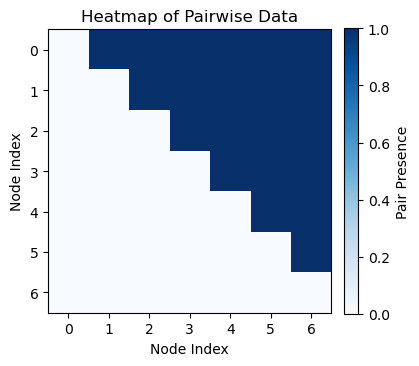

In [42]:
# Initialize a 7x7 grid with zeros
grid_size = 7
heatmap = np.zeros((grid_size, grid_size))

# List of pairs
pairs = [(4, 5),
 (0, 1),
 (0, 2),
 (3, 5),
 (1, 2),
 (3, 4),
 (2, 3),
 (0, 3),
 (1, 3),
 (0, 5),
 (1, 4),
 (1, 5),
 (2, 5),
 (2, 4),
 (5, 6),
 (0, 4),
 (4, 6),
 (1, 6),
 (3, 6),
 (2, 6),
 (0, 6)]

# Fill the heatmap with 1s for the given pairs
for x, y in pairs:
    heatmap[x, y] = 1
    #heatmap[y, x] = 1  # Assuming the pairs are undirected

# Create the heatmap
plt.figure(figsize=(4, 4))
plt.imshow(heatmap, cmap='Blues', origin='upper')
#plt.colorbar(label='Pair Presence')

cbar = plt.colorbar(label='Pair Presence', fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)

plt.title('Heatmap of Pairwise Data')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.xticks(np.arange(grid_size))
plt.yticks(np.arange(grid_size))
plt.grid(False)

# Display the heatmap
plt.show()

In [43]:
adatas_MALDI_cor

[AnnData object with n_obs × n_vars = 23462 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial', 'X_scanorama',
 AnnData object with n_obs × n_vars = 16041 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial', 'X_scanorama',
 AnnData object with n_obs × n_vars = 14048 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial', 'X_scanorama',
 AnnData object with n_obs × n_vars = 42842 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
     var: 'n_cells', 'mean', 'std'
     obsm: 'spatial', 'X_scanorama',
 AnnData object with n_obs × n_vars = 41943 × 218
     obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_

In [44]:
adatas_MALDI_cor_concat = ad.concat(adatas_MALDI_cor, join="inner")

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [45]:
adatas_MALDI_cor_concat

AnnData object with n_obs × n_vars = 324670 × 218
    obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
    obsm: 'spatial', 'X_scanorama'

In [47]:
import time
t0 = time.time()
filePath='/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024'
os.makedirs(filePath, exist_ok=True)
fn = 'adatas_cor_concat_MALDI.h5ad'
fn = os.path.join(filePath, fn)
adatas_MALDI_cor_concat.write(fn)
print('%.1f seconds passed'%(time.time()-t0))

0.6 seconds passed


In [56]:
ad_MALDI = adatas_MALDI_cor_concat.copy()

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [58]:
ad_MALDI

AnnData object with n_obs × n_vars = 324670 × 218
    obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
    obsm: 'spatial', 'X_scanorama'

In [61]:
ad_MALDI.obs

,pos_y,pos_x,pixel_id,group_id,day_id,tissue_id,sample_id,n_genes
0,66,127,group_E0_day_7_tissue_1_posX_127_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,10
1,66,126,group_E0_day_7_tissue_1_posX_126_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,34
2,66,130,group_E0_day_7_tissue_1_posX_130_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,64
3,66,129,group_E0_day_7_tissue_1_posX_129_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,93
4,66,128,group_E0_day_7_tissue_1_posX_128_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,91
...,...,...,...,...,...,...,...,...
50907,348,231,group_4T1_day_14_tissue_5_posX_231_posY_348,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,54
50908,348,230,group_4T1_day_14_tissue_5_posX_230_posY_348,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,61
50909,349,239,group_4T1_day_14_tissue_5_posX_239_posY_349,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,62
50910,349,238,group_4T1_day_14_tissue_5_posX_238_posY_349,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,73


In [97]:
ad_MALDI_metadata_df = pd.DataFrame(ad_MALDI.obs)

In [98]:
pd.DataFrame(ad_MALDI.X)

,0,1,2,3,4,5,6,7,8,9,...,208,209,210,211,212,213,214,215,216,217
0,-0.015342,-0.049294,-0.005890,0.059880,-0.120557,-0.005355,-0.022646,-0.005838,-0.004951,-0.013095,...,-0.005895,-0.045129,-0.006069,-0.036932,-0.059354,-0.065926,-0.005623,-0.018683,-0.006738,-0.006566
1,-0.020155,-0.063611,-0.007483,-0.051219,-0.154118,-0.007121,-0.028933,-0.007675,-0.005914,-0.016692,...,-0.007978,-0.058355,-0.008318,-0.047352,-0.075727,-0.084429,-0.007946,-0.023978,-0.008765,-0.008817
2,-0.021814,-0.070872,-0.008789,-0.058551,-0.146923,-0.010589,-0.034588,-0.009220,-0.007105,-0.018889,...,-0.008085,-0.066629,-0.008370,-0.055524,-0.087946,-0.097534,-0.007991,-0.026151,-0.012035,-0.011173
3,-0.015865,-0.053530,-0.006615,-0.045547,-0.095051,-0.006603,-0.025626,-0.006303,-0.005121,-0.013438,...,-0.005988,-0.051547,-0.007109,-0.041573,-0.068026,-0.075027,-0.005201,-0.020735,-0.009642,-0.010085
4,-0.018433,-0.064661,-0.007879,-0.055186,-0.103861,-0.007791,-0.031044,-0.007317,-0.005958,-0.017031,...,-0.007258,-0.000470,-0.007901,-0.049977,-0.032268,-0.089677,-0.006678,-0.024336,-0.012952,-0.010989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324665,-0.034074,-0.016424,-0.007049,-0.006827,-0.082814,-0.007924,-0.010029,-0.005727,-0.005810,-0.008654,...,-0.006353,-0.007335,-0.009532,0.009228,0.151280,0.112298,-0.006389,-0.024298,-0.019032,-0.008342
324666,-0.025792,0.212602,-0.005938,-0.002195,-0.053661,-0.005821,-0.008766,-0.003965,-0.006454,-0.006090,...,-0.004731,-0.005344,-0.007027,0.027588,0.206304,0.155020,-0.003707,-0.019781,0.137337,-0.005644
324667,-0.016749,-0.008588,-0.006472,0.000698,-0.075051,-0.004543,0.179403,-0.002992,-0.004399,-0.004593,...,-0.002927,-0.003636,0.339916,0.000496,0.178805,0.086236,-0.003217,-0.014763,-0.006398,-0.001767
324668,0.033432,0.125120,-0.002640,0.002389,-0.032990,-0.002974,0.213525,-0.001718,-0.003016,-0.002673,...,-0.001653,-0.002776,0.244040,0.016659,0.183619,0.097349,-0.002304,-0.007558,0.087096,-0.002604


In [100]:
ad_MALDI_data_df = pd.DataFrame(ad_MALDI.X)

In [110]:
ad_MALDI_data_df.columns = metabolite_names

In [111]:
ad_MALDI_data_df

,Pyruvate_M.H,Alanine_M.H,Lactic acid_M.H,NaCl_M.Cl,H2SO4.H_M.Cl,Phosphate_M.H,Serine_M.H,KCl_M.Cl,Uracil_M.H,Dihydrouracil_M.H,...,PA.45.9._M.H,PS.38.3._M.H,PG.40.7._M.H,PS.40.6._M.H,PI.34.1._M.H,PS.40.5._M.H,PI.34.0._M.H,PS.40.4._M.H,PI.36.2._M.H,PI.38.4._M.H
0,-0.015342,-0.049294,-0.005890,0.059880,-0.120557,-0.005355,-0.022646,-0.005838,-0.004951,-0.013095,...,-0.005895,-0.045129,-0.006069,-0.036932,-0.059354,-0.065926,-0.005623,-0.018683,-0.006738,-0.006566
1,-0.020155,-0.063611,-0.007483,-0.051219,-0.154118,-0.007121,-0.028933,-0.007675,-0.005914,-0.016692,...,-0.007978,-0.058355,-0.008318,-0.047352,-0.075727,-0.084429,-0.007946,-0.023978,-0.008765,-0.008817
2,-0.021814,-0.070872,-0.008789,-0.058551,-0.146923,-0.010589,-0.034588,-0.009220,-0.007105,-0.018889,...,-0.008085,-0.066629,-0.008370,-0.055524,-0.087946,-0.097534,-0.007991,-0.026151,-0.012035,-0.011173
3,-0.015865,-0.053530,-0.006615,-0.045547,-0.095051,-0.006603,-0.025626,-0.006303,-0.005121,-0.013438,...,-0.005988,-0.051547,-0.007109,-0.041573,-0.068026,-0.075027,-0.005201,-0.020735,-0.009642,-0.010085
4,-0.018433,-0.064661,-0.007879,-0.055186,-0.103861,-0.007791,-0.031044,-0.007317,-0.005958,-0.017031,...,-0.007258,-0.000470,-0.007901,-0.049977,-0.032268,-0.089677,-0.006678,-0.024336,-0.012952,-0.010989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324665,-0.034074,-0.016424,-0.007049,-0.006827,-0.082814,-0.007924,-0.010029,-0.005727,-0.005810,-0.008654,...,-0.006353,-0.007335,-0.009532,0.009228,0.151280,0.112298,-0.006389,-0.024298,-0.019032,-0.008342
324666,-0.025792,0.212602,-0.005938,-0.002195,-0.053661,-0.005821,-0.008766,-0.003965,-0.006454,-0.006090,...,-0.004731,-0.005344,-0.007027,0.027588,0.206304,0.155020,-0.003707,-0.019781,0.137337,-0.005644
324667,-0.016749,-0.008588,-0.006472,0.000698,-0.075051,-0.004543,0.179403,-0.002992,-0.004399,-0.004593,...,-0.002927,-0.003636,0.339916,0.000496,0.178805,0.086236,-0.003217,-0.014763,-0.006398,-0.001767
324668,0.033432,0.125120,-0.002640,0.002389,-0.032990,-0.002974,0.213525,-0.001718,-0.003016,-0.002673,...,-0.001653,-0.002776,0.244040,0.016659,0.183619,0.097349,-0.002304,-0.007558,0.087096,-0.002604


In [112]:
# Define the file path where you want to save the CSV
file_path = '/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024/ad_MALDI_metadata_df.csv'

# Write the dataframe to CSV
ad_MALDI_metadata_df.to_csv(file_path, index=False)

In [113]:
# Define the file path where you want to save the CSV
file_path = '/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024/ad_MALDI_data_df.csv'

# Write the dataframe to CSV
ad_MALDI_data_df.to_csv(file_path, index=False)

In [57]:
ad_MALDI.X.shape

(324670, 218)

In [88]:
#ot.tic()
#sc.pp.pca(ad_MALDI, n_comps=60)
#sc.pl.pca_variance_ratio(ad_MALDI, log=True, n_pcs=60)
#ot.toc()

In [53]:
ot.tic()
sc.pp.neighbors(ad_MALDI, use_rep="X_scanorama", n_neighbors=15, n_pcs=30)
umap_kwargs = dict()
print("Running UMAP on Input Dataset...")
sc.tl.umap(ad_MALDI, 
           #a = 0.9922, 
           #b = 1.112, 
           #min_dist = 0.5, # scanpy default
           #spread = 1,     # scanpy default
           #min_dist = 0.3, # seurat default
           #spread = 1,     # seurat default
           min_dist = 0.01, # revised setting
           spread = 1,     # revised setting
           n_components=3, 
           **umap_kwargs)
ot.toc()

Running UMAP on Input Dataset...
Elapsed time : 193.40072298049927 s


193.40072298049927

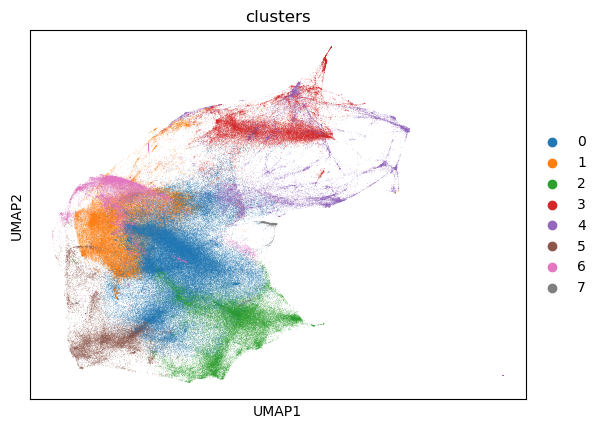

In [54]:
sc.tl.louvain(ad_MALDI, key_added='clusters', resolution = 0.3)
sc.pl.umap(ad_MALDI, color='clusters')

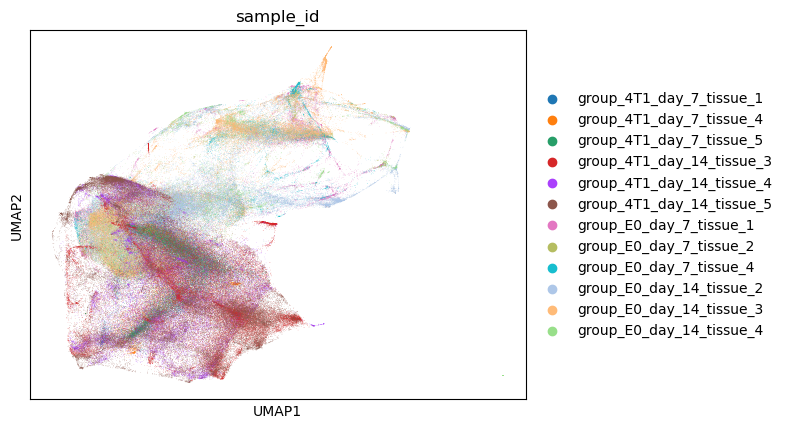

In [55]:
sc.pl.umap(ad_MALDI, color='sample_id')

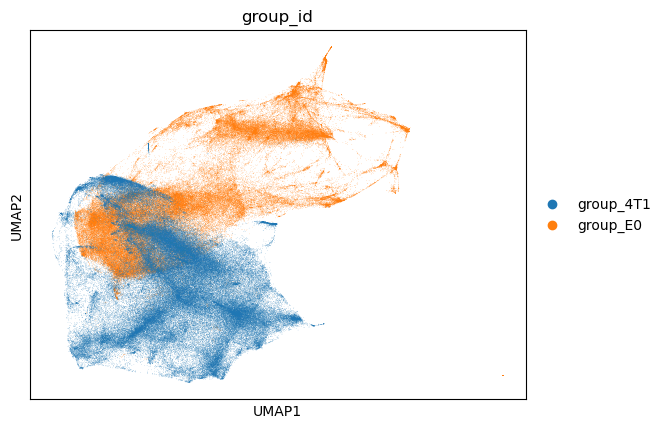

In [56]:
sc.pl.umap(ad_MALDI, color='group_id')

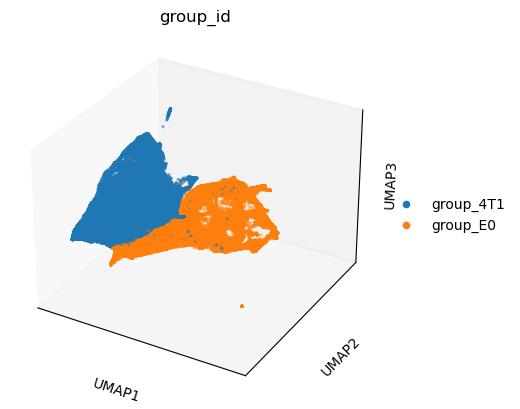

In [59]:
sc.pl.umap(ad_MALDI, color='group_id', projection='3d')

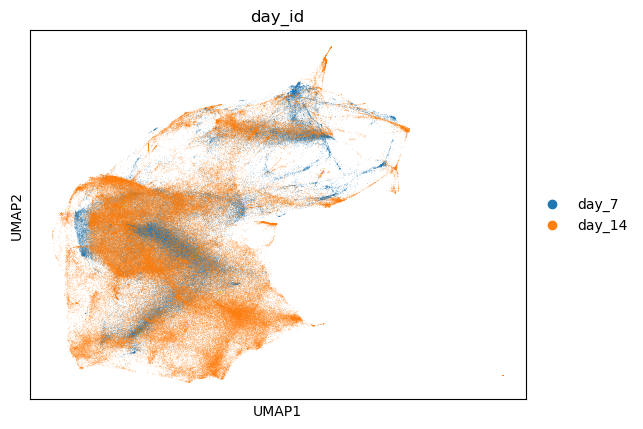

In [57]:
sc.pl.umap(ad_MALDI, color='day_id')

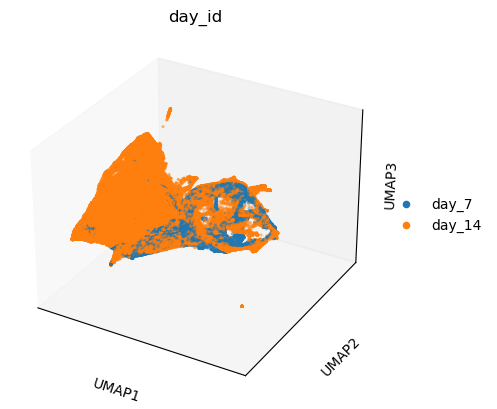

In [60]:
sc.pl.umap(ad_MALDI, color='day_id', projection="3d")

In [61]:
ot.tic()
sc.pp.neighbors(ad_MALDI, use_rep="X_scanorama", n_neighbors=15, n_pcs=30)
umap_kwargs = dict()
print("Running UMAP on Input Dataset...")
sc.tl.umap(ad_MALDI, 
           #a = 0.9922, 
           #b = 1.112, 
           #min_dist = 0.5, # scanpy default
           #spread = 1,     # scanpy default
           #min_dist = 0.3, # seurat default
           #spread = 1,     # seurat default
           min_dist = 0.3, # revised setting
           spread = 1,     # revised setting
           n_components=3, 
           **umap_kwargs)
ot.toc()

Running UMAP on Input Dataset...
Elapsed time : 205.49180006980896 s


205.49180006980896

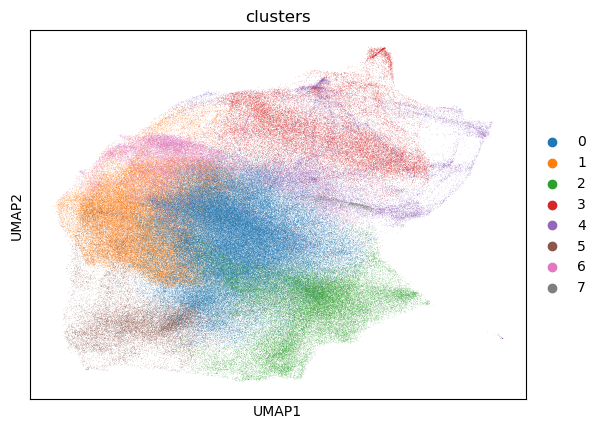

In [62]:
sc.tl.louvain(ad_MALDI, key_added='clusters', resolution = 0.3)
sc.pl.umap(ad_MALDI, color='clusters')

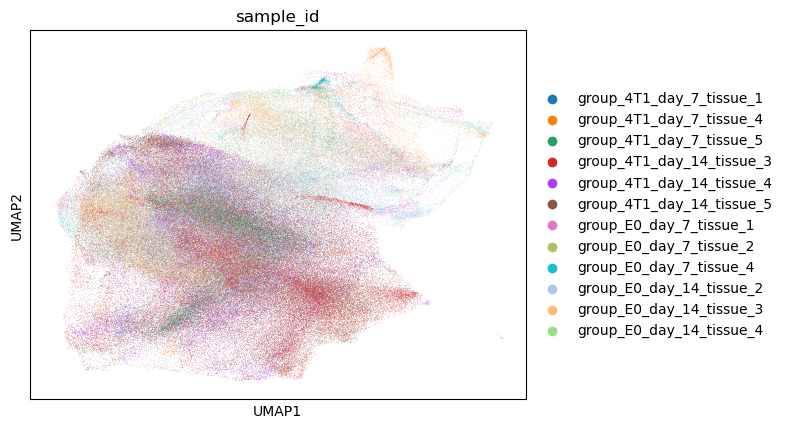

In [49]:
sc.pl.umap(ad_MALDI, color='sample_id')

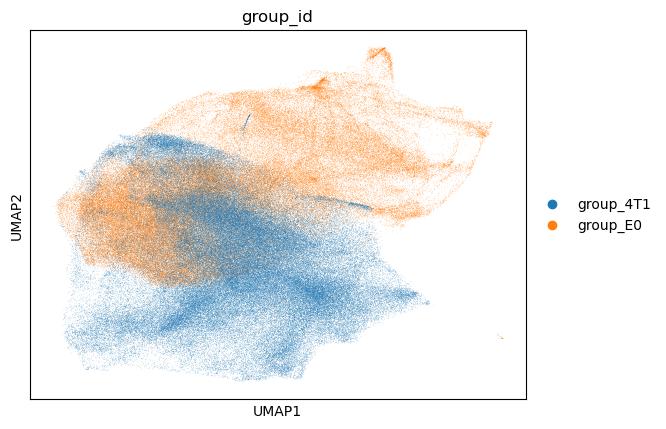

In [50]:
sc.pl.umap(ad_MALDI, color='group_id')

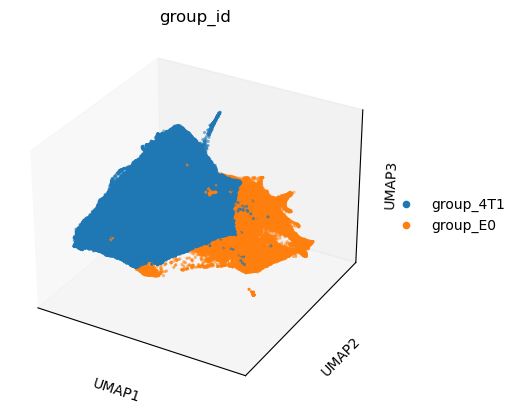

In [63]:
sc.pl.umap(ad_MALDI, color='group_id', projection='3d')

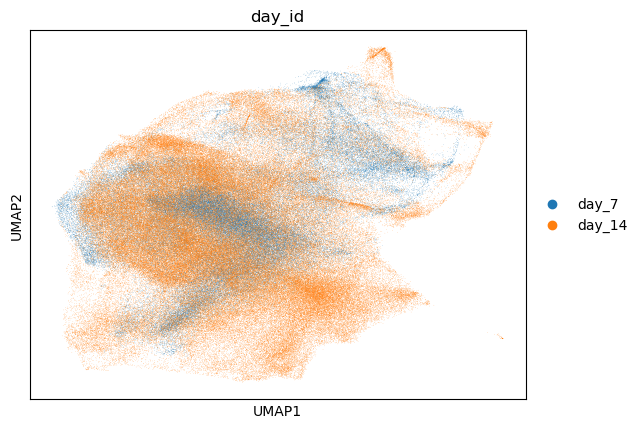

In [51]:
sc.pl.umap(ad_MALDI, color='day_id')

/Users/lium2/tmp/ipykernel_53217/1791994701.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_data in df.groupby('cluster_id'):
/Users/lium2/tmp/ipykernel_53217/1791994701.py:52: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  legend_legendHandles = legend.legendHandles


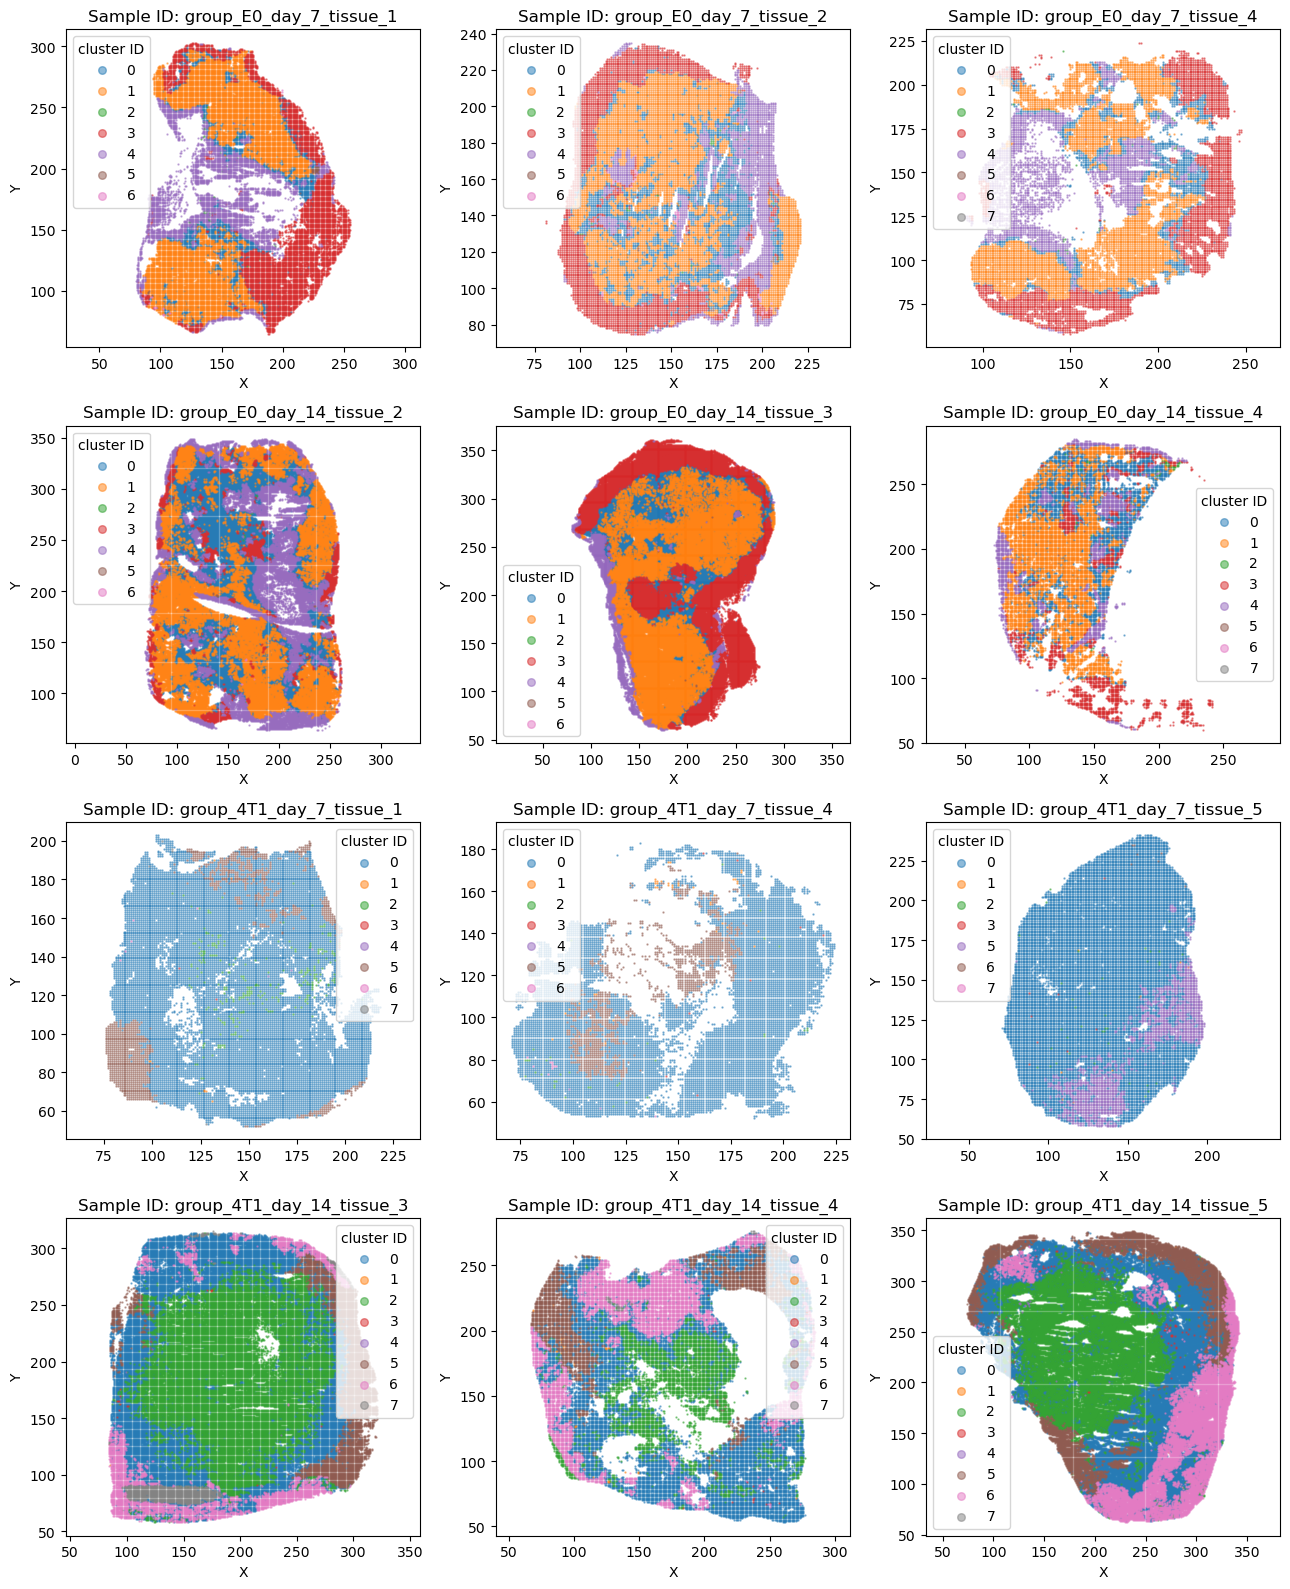

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample list of sample IDs
sample_ids = [
    'group_E0_day_7_tissue_1', 'group_E0_day_7_tissue_2', 'group_E0_day_7_tissue_4',
    'group_E0_day_14_tissue_2', 'group_E0_day_14_tissue_3', 'group_E0_day_14_tissue_4',
    'group_4T1_day_7_tissue_1', 'group_4T1_day_7_tissue_4', 'group_4T1_day_7_tissue_5',
    'group_4T1_day_14_tissue_3', 'group_4T1_day_14_tissue_4', 'group_4T1_day_14_tissue_5',
]

# Number of columns for the plot layout
n_cols = 3
n_rows = (len(sample_ids) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, sample_id in enumerate(sample_ids):
    # Select data for the current sample_id
    ad_MALDI_group = ad_MALDI[ad_MALDI.obs['sample_id'] == sample_id]
    ad_MALDI_plot = ad_MALDI_group

    # Example DataFrame
    data = {
        'x': ad_MALDI_plot.obs['pos_x'],
        'y': ad_MALDI_plot.obs['pos_y'],
        'cluster_id': ad_MALDI_plot.obs['clusters']
    }
    df = pd.DataFrame(data)

    # Create a scatter plot in the current subplot
    ax = axes[i]

    # Group the DataFrame by 'group_id' and iterate over each group
    for group_name, group_data in df.groupby('cluster_id'):
        ax.scatter(group_data['x'], group_data['y'], label=group_name, s=0.5, alpha=0.5)

    # Title and labels
    ax.set_title(f'Sample ID: {sample_id}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.axis('equal')

    # Create legend
    legend = ax.legend(title='cluster ID')

    # Increase dot size in the legend
    legend_legendHandles = legend.legendHandles
    for handle in legend_legendHandles:
        handle._sizes = [30]  # Change 30 to the desired size

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

/Users/lium2/tmp/ipykernel_46814/2834187464.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_data in df.groupby('cluster_id'):
/Users/lium2/tmp/ipykernel_46814/2834187464.py:51: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  legend_legendHandles = legend.legendHandles


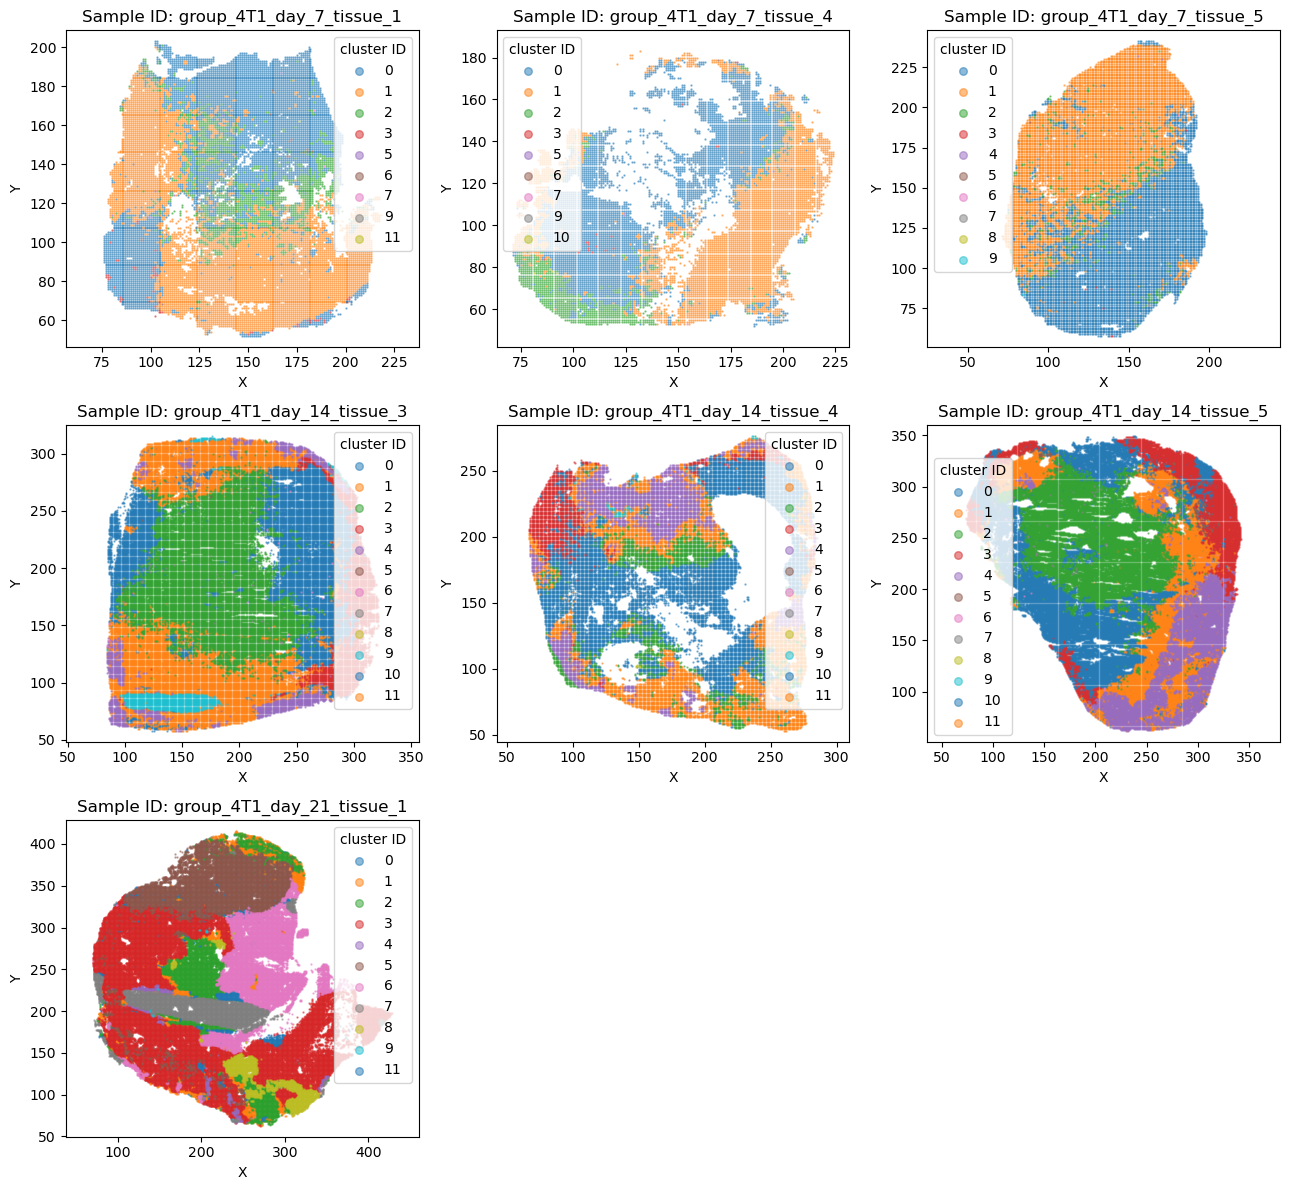

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample list of sample IDs
sample_ids = [
    'group_4T1_day_7_tissue_1', 'group_4T1_day_7_tissue_4', 'group_4T1_day_7_tissue_5',
    'group_4T1_day_14_tissue_3', 'group_4T1_day_14_tissue_4', 'group_4T1_day_14_tissue_5',
    'group_4T1_day_21_tissue_1'
]

# Number of columns for the plot layout
n_cols = 3
n_rows = (len(sample_ids) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, sample_id in enumerate(sample_ids):
    # Select data for the current sample_id
    ad_MALDI_group = ad_MALDI[ad_MALDI.obs['sample_id'] == sample_id]
    ad_MALDI_plot = ad_MALDI_group

    # Example DataFrame
    data = {
        'x': ad_MALDI_plot.obs['pos_x'],
        'y': ad_MALDI_plot.obs['pos_y'],
        'cluster_id': ad_MALDI_plot.obs['clusters']
    }
    df = pd.DataFrame(data)

    # Create a scatter plot in the current subplot
    ax = axes[i]

    # Group the DataFrame by 'group_id' and iterate over each group
    for group_name, group_data in df.groupby('cluster_id'):
        ax.scatter(group_data['x'], group_data['y'], label=group_name, s=0.5, alpha=0.5)

    # Title and labels
    ax.set_title(f'Sample ID: {sample_id}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.axis('equal')

    # Create legend
    legend = ax.legend(title='cluster ID')

    # Increase dot size in the legend
    legend_legendHandles = legend.legendHandles
    for handle in legend_legendHandles:
        handle._sizes = [30]  # Change 30 to the desired size

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [48]:
import time
t0 = time.time()
filePath='/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/with_spatial_smoothing/05_26_2024'
fn = 'adata_MALDI_scanorama_corrected_scanpy.h5ad'
fn = os.path.join(filePath, fn)
ad_MALDI.write_h5ad(fn,compression='gzip')
print('%.1f seconds passed'%(time.time()-t0))
ad_MALDI

50.8 seconds passed


AnnData object with n_obs × n_vars = 502497 × 218
    obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes', 'clusters'
    uns: 'neighbors', 'umap', 'clusters', 'clusters_colors', 'sample_id_colors', 'group_id_colors', 'day_id_colors'
    obsm: 'spatial', 'X_scanorama', 'X_umap'
    obsp: 'distances', 'connectivities'

In [42]:
# run scanorama.integrate
ot.tic()
kwargs = dict(alpha=0.0, datasets_labels=datasets_labels, knn=15)
adatas_mIF_cor = correct_scanpy_with_specific_pairs(adatas_mIF, return_dimred=True, return_dense=True, dimred=4, verbose=2, **kwargs)
ot.toc()

Found 5 genes among all datasets
[[0.         0.68150365 0.70152335 0.84519649 0.72559884 0.67366092
  0.58429405 0.54965021 0.59584049 0.7904697  0.56133322 0.79281391]
 [0.         0.         0.5748861  0.8483885  0.71566611 0.5139103
  0.49552421 0.48736883 0.55083848 0.8119818  0.60245621 0.82644474]
 [0.         0.         0.         0.87976936 0.70835706 0.46333998
  0.52292141 0.45034979 0.52562642 0.81669989 0.57588269 0.80830011]
 [0.         0.         0.         0.         0.78971461 0.86981297
  0.796555   0.77331908 0.81732535 0.82883619 0.7088882  0.82715559]
 [0.         0.         0.         0.         0.         0.8212107
  0.73653872 0.73853478 0.78118149 0.8709439  0.73996077 0.7872589 ]
 [0.         0.         0.         0.         0.         0.
  0.52470336 0.46414691 0.61600858 0.85372394 0.64101361 0.82188108]
 [0.         0.         0.         0.         0.         0.
  0.         0.66537116 0.68777974 0.90254984 0.73789502 0.89997287]
 [0.         0.         0.

1115.073861837387

In [43]:
adatas_mIF_cor_concat = ad.concat(adatas_mIF_cor, join="inner")

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [44]:
adatas_mIF_cor_concat

AnnData object with n_obs × n_vars = 324670 × 5
    obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes'
    obsm: 'spatial', 'X_scanorama'

In [51]:
import time
t0 = time.time()
filePath='/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024'
fn = 'adatas_mIF_cor_concat_MALDI.h5ad'
fn = os.path.join(filePath, fn)
adatas_mIF_cor_concat.write(fn)
print('%.1f seconds passed'%(time.time()-t0))

0.4 seconds passed


In [52]:
ad_mIF = adatas_mIF_cor_concat.copy()

/Users/lium2/anaconda3/envs/itk_align/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [60]:
ad_mIF.obs

,pos_y,pos_x,pixel_id,group_id,day_id,tissue_id,sample_id,n_genes
0,66,127,group_E0_day_7_tissue_1_posX_127_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,4
1,66,126,group_E0_day_7_tissue_1_posX_126_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,4
2,66,130,group_E0_day_7_tissue_1_posX_130_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,5
3,66,129,group_E0_day_7_tissue_1_posX_129_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,5
4,66,128,group_E0_day_7_tissue_1_posX_128_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,5
...,...,...,...,...,...,...,...,...
50907,348,231,group_4T1_day_14_tissue_5_posX_231_posY_348,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,5
50908,348,230,group_4T1_day_14_tissue_5_posX_230_posY_348,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,4
50909,349,239,group_4T1_day_14_tissue_5_posX_239_posY_349,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,5
50910,349,238,group_4T1_day_14_tissue_5_posX_238_posY_349,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,5


In [55]:
ad_mIF.X.shape

(324670, 5)

In [79]:
ot.tic()
sc.pp.neighbors(ad_mIF, use_rep="X_scanorama", n_neighbors=15, n_pcs=4)
umap_kwargs = dict()
print("Running UMAP on Input Dataset...")
sc.tl.umap(ad_mIF, 
           #a = 0.9922, 
           #b = 1.112, 
           #min_dist = 0.5, # scanpy default
           #spread = 1,     # scanpy default
           #min_dist = 0.3, # seurat default
           #spread = 1,     # seurat default
           min_dist = 0.3, # revised setting
           spread = 1,     # revised setting
           n_components=3, 
           **umap_kwargs)
ot.toc()

Running UMAP on Input Dataset...
Elapsed time : 161.85297989845276 s


161.85297989845276

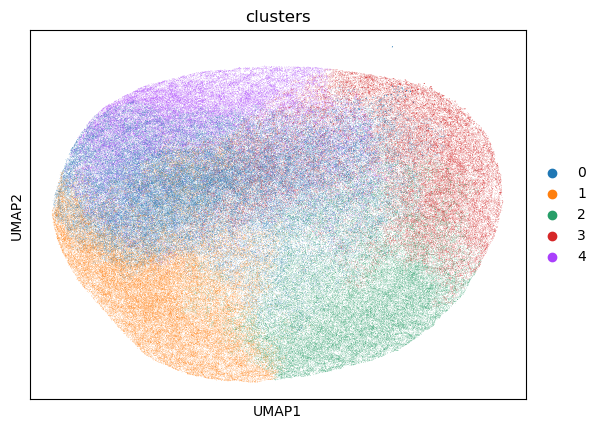

In [80]:
sc.tl.louvain(ad_mIF, key_added='clusters', resolution = 0.1)
sc.pl.umap(ad_mIF, color='clusters')

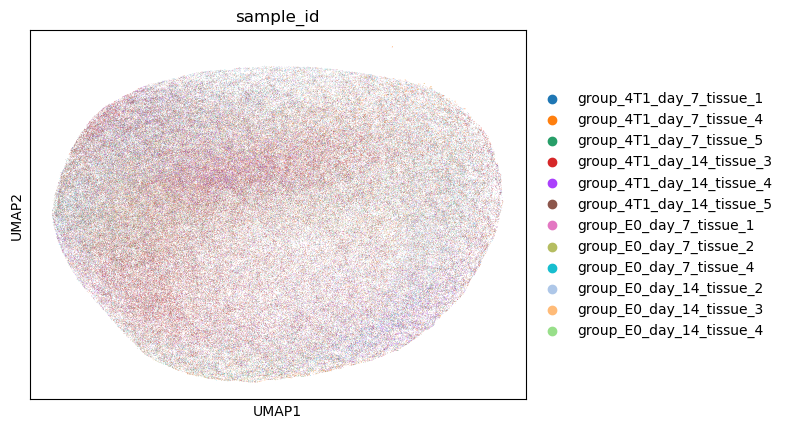

In [81]:
sc.pl.umap(ad_mIF, color='sample_id')

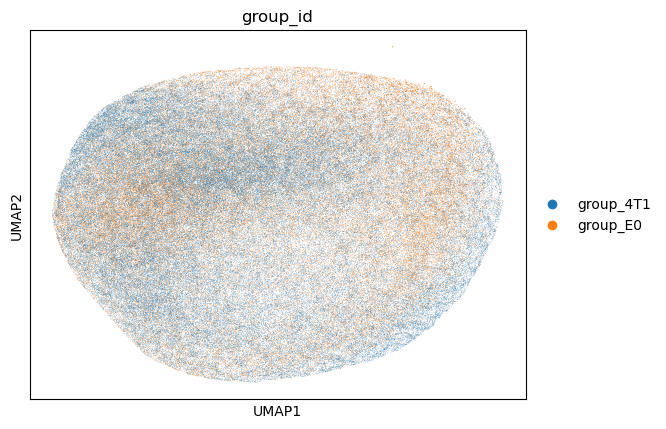

In [82]:
sc.pl.umap(ad_mIF, color='group_id')

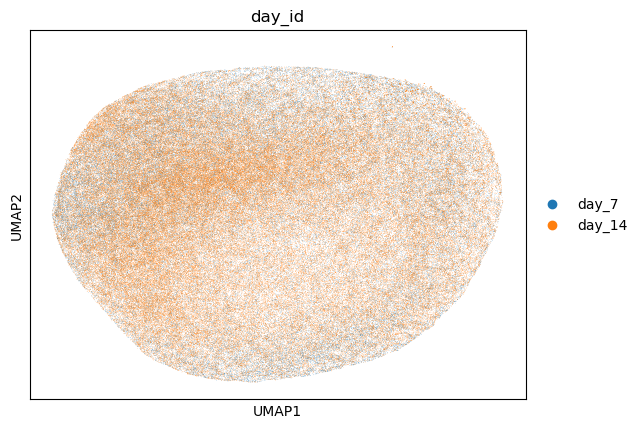

In [83]:
sc.pl.umap(ad_mIF, color='day_id')

/Users/lium2/tmp/ipykernel_27871/1513885443.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_data in df.groupby('cluster_id'):
/Users/lium2/tmp/ipykernel_27871/1513885443.py:52: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  legend_legendHandles = legend.legendHandles


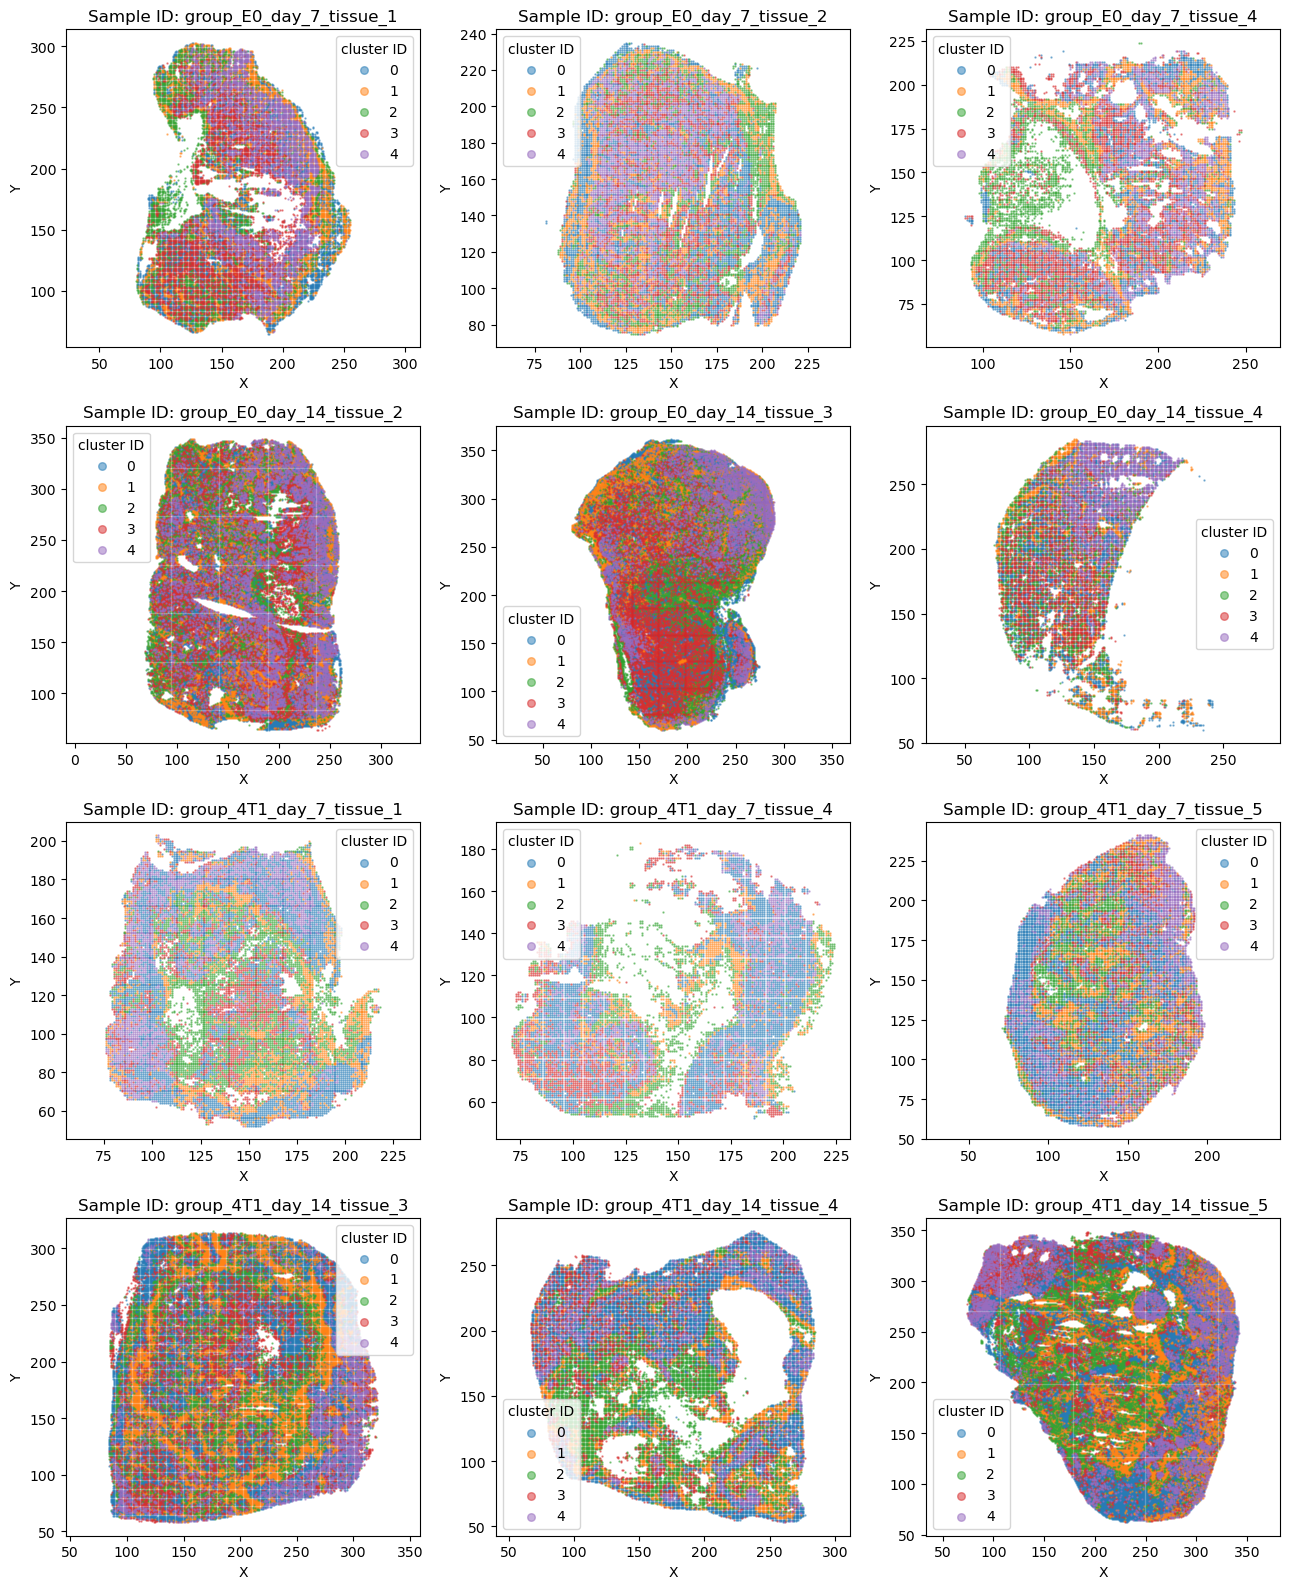

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample list of sample IDs
sample_ids = [
    'group_E0_day_7_tissue_1', 'group_E0_day_7_tissue_2', 'group_E0_day_7_tissue_4',
    'group_E0_day_14_tissue_2', 'group_E0_day_14_tissue_3', 'group_E0_day_14_tissue_4',
    'group_4T1_day_7_tissue_1', 'group_4T1_day_7_tissue_4', 'group_4T1_day_7_tissue_5',
    'group_4T1_day_14_tissue_3', 'group_4T1_day_14_tissue_4', 'group_4T1_day_14_tissue_5'
]

# Number of columns for the plot layout
n_cols = 3
n_rows = (len(sample_ids) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, sample_id in enumerate(sample_ids):
    # Select data for the current sample_id
    ad_mIF_group = ad_mIF[ad_mIF.obs['sample_id'] == sample_id]
    ad_mIF_plot = ad_mIF_group

    # Example DataFrame
    data = {
        'x': ad_mIF_plot.obs['pos_x'],
        'y': ad_mIF_plot.obs['pos_y'],
        'cluster_id': ad_mIF_plot.obs['clusters']
    }
    df = pd.DataFrame(data)

    # Create a scatter plot in the current subplot
    ax = axes[i]

    # Group the DataFrame by 'group_id' and iterate over each group
    for group_name, group_data in df.groupby('cluster_id'):
        ax.scatter(group_data['x'], group_data['y'], label=group_name, s=0.5, alpha=0.5)

    # Title and labels
    ax.set_title(f'Sample ID: {sample_id}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.axis('equal')

    # Create legend
    legend = ax.legend(title='cluster ID')

    # Increase dot size in the legend
    legend_legendHandles = legend.legendHandles
    for handle in legend_legendHandles:
        handle._sizes = [30]  # Change 30 to the desired size

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [119]:
import time
t0 = time.time()
filePath='/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024'
fn = 'adata_mIF_scanorama_corrected_scanpy.h5ad'
fn = os.path.join(filePath, fn)
ad_mIF.write_h5ad(fn,compression='gzip')
print('%.1f seconds passed'%(time.time()-t0))
ad_mIF

5.3 seconds passed


AnnData object with n_obs × n_vars = 324670 × 5
    obs: 'pos_y', 'pos_x', 'pixel_id', 'group_id', 'day_id', 'tissue_id', 'sample_id', 'n_genes', 'clusters'
    uns: 'neighbors', 'umap', 'clusters', 'clusters_colors', 'sample_id_colors', 'group_id_colors', 'day_id_colors', 'dendrogram_clusters'
    obsm: 'spatial', 'X_scanorama', 'X_umap'
    obsp: 'distances', 'connectivities'

In [92]:
pd.DataFrame(ad_mIF.obs)

,pos_y,pos_x,pixel_id,group_id,day_id,tissue_id,sample_id,n_genes,clusters
0,66,127,group_E0_day_7_tissue_1_posX_127_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,4,0
1,66,126,group_E0_day_7_tissue_1_posX_126_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,4,0
2,66,130,group_E0_day_7_tissue_1_posX_130_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,5,0
3,66,129,group_E0_day_7_tissue_1_posX_129_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,5,0
4,66,128,group_E0_day_7_tissue_1_posX_128_posY_66,group_E0,day_7,tissue_1,group_E0_day_7_tissue_1,5,1
...,...,...,...,...,...,...,...,...,...
50907,348,231,group_4T1_day_14_tissue_5_posX_231_posY_348,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,5,0
50908,348,230,group_4T1_day_14_tissue_5_posX_230_posY_348,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,4,0
50909,349,239,group_4T1_day_14_tissue_5_posX_239_posY_349,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,5,1
50910,349,238,group_4T1_day_14_tissue_5_posX_238_posY_349,group_4T1,day_14,tissue_5,group_4T1_day_14_tissue_5,5,0


In [91]:
ad_mIF_metadata_df = pd.DataFrame(ad_mIF.obs)

In [89]:
pd.DataFrame(ad_mIF.X)

,0,1,2,3,4
0,0.168360,0.027813,0.853722,0.334023,-0.106807
1,-0.615244,-0.375375,0.450688,-0.092086,-0.269238
2,0.594182,0.138400,0.606003,0.461976,0.215412
3,0.510374,0.008177,0.579547,0.591362,0.232569
4,0.371615,0.371445,0.443549,0.608216,-0.326226
...,...,...,...,...,...
324665,0.194626,-0.587405,0.116522,-0.633475,-0.350853
324666,-0.374281,-0.521429,-0.200342,-0.639381,-0.329887
324667,0.685604,0.204597,0.454339,0.406915,-0.055787
324668,0.466688,0.351821,0.634594,0.242201,0.165985


In [93]:
ad_mIF_data_df = pd.DataFrame(ad_mIF.X)

In [114]:
ad_mIF_data_df.columns = protein_marker_names

In [115]:
ad_mIF_data_df

,DAPI_intensity,macrophages_intensity,Ki67_intensity,vasculature_intensity,fibroblast_intensity
0,0.168360,0.027813,0.853722,0.334023,-0.106807
1,-0.615244,-0.375375,0.450688,-0.092086,-0.269238
2,0.594182,0.138400,0.606003,0.461976,0.215412
3,0.510374,0.008177,0.579547,0.591362,0.232569
4,0.371615,0.371445,0.443549,0.608216,-0.326226
...,...,...,...,...,...
324665,0.194626,-0.587405,0.116522,-0.633475,-0.350853
324666,-0.374281,-0.521429,-0.200342,-0.639381,-0.329887
324667,0.685604,0.204597,0.454339,0.406915,-0.055787
324668,0.466688,0.351821,0.634594,0.242201,0.165985


In [116]:
# Define the file path where you want to save the CSV
file_path = '/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024/ad_mIF_metadata_df.csv'

# Write the dataframe to CSV
ad_mIF_metadata_df.to_csv(file_path, index=False)


In [117]:
# Define the file path where you want to save the CSV
file_path = '/Users/lium2/work/Ed_lab/Perry_lab_project/co_register_intensity/without_spatial_smoothing/07_07_2024/ad_mIF_data_df.csv'

# Write the dataframe to CSV
ad_mIF_data_df.to_csv(file_path, index=False)


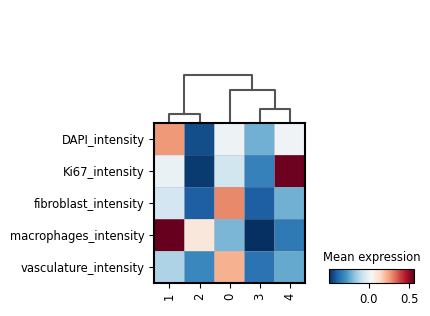

In [86]:
sc.pl.matrixplot(
    ad_mIF,
    ad_mIF.var_names.tolist(),
    'clusters',
    dendrogram=True,
    colorbar_title="Mean expression",
    cmap="RdBu_r", 
    swap_axes=True,
)

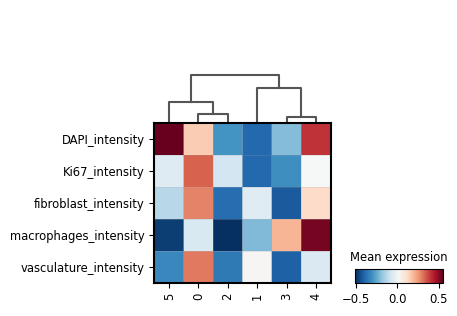

In [76]:
sc.pl.matrixplot(
    ad_mIF,
    ad_mIF.var_names.tolist(),
    'clusters',
    dendrogram=True,
    colorbar_title="Mean expression",
    cmap="RdBu_r", 
    swap_axes=True,
)

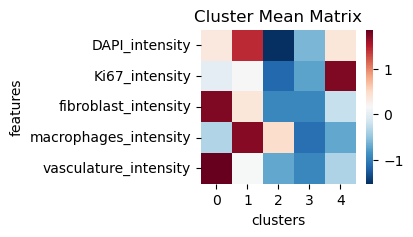

In [73]:
import seaborn as sns
from scipy.stats import zscore

cluster_means = []

cluster_len = len(ad_mIF.obs['clusters'].unique())

feature_names = ad_mIF.var_names.tolist()

# Loop through clusters 0 to 11
for cluster in range( cluster_len ):
    # Extract the data matrix for the current cluster
    dat_matrix = ad_mIF[ad_mIF.obs['clusters'] == str(cluster)].X
    
    # Compute the mean for the current cluster
    cluster_mean = np.mean(dat_matrix, axis=0)
    
    # Append the cluster mean to the list
    cluster_means.append(cluster_mean)

# Convert the list of cluster means to a numpy array (matrix)
cluster_mean_matrix = np.array(cluster_means)

plot_matrix = cluster_mean_matrix.T

zscored_matrix = zscore(plot_matrix, axis=1)

# Create a heatmap
plt.figure(figsize=(2.5, 2))
#sns.heatmap(zscored_matrix, cmap='RdBu_r', annot=False)
sns.heatmap(zscored_matrix, 
            cmap='RdBu_r', 
            annot=False, 
            xticklabels=range(cluster_len), 
            yticklabels=feature_names)

# Create a clustermap
#sns.clustermap(zscored_matrix, 
#               cmap='RdBu_r', 
#               col_cluster=True, 
#               row_cluster=False, 
#               xticklabels=range(cluster_len), 
#               yticklabels=feature_names)

# Add titles and labels
plt.title('Cluster Mean Matrix')
plt.xlabel('clusters')
plt.ylabel('features')

# Show the plot
plt.show()

In [74]:
ad_mIF_E0_group = ad_mIF[ad_mIF.obs["group_id"] == 'group_E0' ]

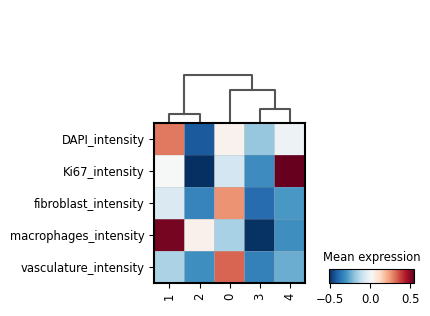

In [75]:
sc.pl.matrixplot(
    ad_mIF_E0_group,
    ad_mIF_E0_group.var_names.tolist(),
    'clusters',
    dendrogram=True,
    colorbar_title="Mean expression",
    cmap="RdBu_r", 
    swap_axes=True,
)

In [76]:
ad_mIF_4T1_group = ad_mIF[ad_mIF.obs["group_id"] == 'group_4T1' ]

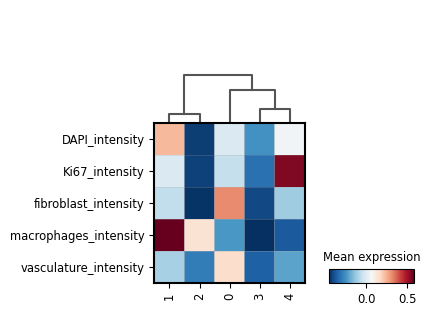

In [77]:
sc.pl.matrixplot(
    ad_mIF_4T1_group,
    ad_mIF_4T1_group.var_names.tolist(),
    'clusters',
    dendrogram=True,
    colorbar_title="Mean expression",
    cmap="RdBu_r", 
    swap_axes=True,
)